# Análisis 6: Segmentación Automática de Perfiles Tácticos
## Strikers vs. Grapplers en la UFC (1994–2026)

**Proyecto Integrador de Aprendizaje — Minería de Datos**  

---

### Objetivo
Agrupar automáticamente a los peleadores de la UFC en clústeres basados en su **comportamiento dentro del octágono** (derribos, golpes significativos e intentos de sumisión), sin usar etiquetas previas, para descubrir una **taxonomía táctica natural** de los estilos de pelea.

### Pregunta de investigación
¿Pueden identificarse de forma automática perfiles tácticos distintos (p. ej. *strikers* puros, *grapplers* dominantes, peleadores híbridos) a partir únicamente de las estadísticas de combate, sin conocer de antemano el estilo declarado del peleador?

### Técnica empleada
**K-Means Clustering** — algoritmo de **aprendizaje no supervisado** que agrupa observaciones en *K* clústeres minimizando la distancia de cada punto al centroide de su grupo.

**Parámetros que se exploran:**
- **Centroides:** punto promedio que representa cada clúster.
- **Inercia:** suma de distancias cuadradas de cada punto a su centroide (medida de cohesión interna).
- **Método del Codo:** técnica para determinar el número óptimo de clústeres *K*.
- **Silhouette Score:** métrica complementaria para validar la calidad de los clústeres.

### Variables del análisis principal
Las tres variables se calculan **por cada 15 minutos de pelea** (estándar oficial de UFC Stats), agregando todos los combates de cada peleador:

| Variable | Descripción |
|---|---|
| `avg_TD_landed_per15` | Promedio de **derribos exitosos** por cada 15 min |
| `avg_SIG_landed_per15` | Promedio de **golpes significativos conectados** por cada 15 min |
| `avg_SUB_att_per15` | Promedio de **intentos de sumisión** por cada 15 min |

### Datasets
- `ufc-dataset/ufc_gold_dataset_final.csv` — 8551 combates registrados (1994–2026), 37 columnas con estadísticas por pelea.
- `ufc-dataset/ufc_fighters_final.csv` — 4455 peleadores, 18 columnas (usado como referencia complementaria).


## 1. Librerías utilizadas

Se importan las librerías necesarias para todo el análisis. Cada bloque está agrupado por propósito:

- **Manipulación de datos:** `pandas` y `numpy` para cargar y transformar los datasets.
- **Visualización:** `matplotlib` y `seaborn` para gráficas estáticas; `mpl_toolkits.mplot3d` para el scatter 3D de clústeres.
- **Modelado (scikit-learn):**
  - `StandardScaler` para escalar las variables (las features tienen escalas muy distintas: golpes ~30, derribos ~1, sumisiones ~0.3).
  - `KMeans` para el clustering principal.
  - `PCA` para proyectar los clústeres a 2D y visualizarlos limpiamente.
  - `silhouette_score` para validar la calidad del agrupamiento.

También se configura el estilo visual de las gráficas y la semilla aleatoria para garantizar **reproducibilidad** del experimento.

In [34]:
# Manipulacion de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (necesario para proyeccion 3D)

# Modelado: aprendizaje no supervisado
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Configuracion estetica global de las graficas
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Semilla aleatoria para reproducibilidad de K-Means
RANDOM_STATE = 42

# Suprimir warnings de versiones (mantiene el notebook limpio para el PDF final)
import warnings
warnings.filterwarnings("ignore")

print("Librerias cargadas correctamente.")
print(f"Version de pandas: {pd.__version__}")
print(f"Version de numpy:  {np.__version__}")

Librerias cargadas correctamente.
Version de pandas: 3.0.1
Version de numpy:  2.4.3


## 2. Carga del dataset

Para este análisis se utiliza **`ufc_gold_dataset_final.csv`**, que contiene una fila por combate con las estadísticas de ambos peleadores (prefijos `F1_` y `F2_`). Este dataset es la fuente principal porque permite calcular el comportamiento **real dentro del octágono** de cada peleador (derribos ejecutados, golpes conectados, intentos de sumisión).

El dataset complementario `ufc_fighters_final.csv` (estadísticas agregadas por peleador) **no se usa para el clustering** porque:

1. Sus métricas ya vienen pre-promediadas por UFC Stats, lo que limita el control sobre la normalización.
2. Necesitamos sumar totales por peleador y dividir por el tiempo total peleado para aplicar la normalización **por 15 minutos** (estándar UFC).
3. Contiene nulos en columnas físicas (Reach, Stance, DOB) que no son relevantes para nuestro análisis táctico.

Se muestra a continuación la dimensión, los tipos de datos y las primeras filas del dataset cargado, para verificar la calidad y estructura de la información antes de proceder.

In [35]:
# Ruta al dataset de combates
RUTA_FIGHTS = "ufc-dataset/ufc_gold_dataset_final.csv"

# Carga del CSV en un DataFrame de pandas
df_fights = pd.read_csv(RUTA_FIGHTS)

# Verificacion basica de la carga
print(f"Dataset cargado: {RUTA_FIGHTS}")
print(f"Dimensiones: {df_fights.shape[0]:,} combates x {df_fights.shape[1]} columnas")
print(f"Rango temporal: {df_fights['Event_Date'].min()} -> {df_fights['Event_Date'].max()}")
print(f"Peleadores unicos: {pd.concat([df_fights['Fighter_1'], df_fights['Fighter_2']]).nunique():,}")

Dataset cargado: ufc-dataset/ufc_gold_dataset_final.csv
Dimensiones: 8,551 combates x 37 columnas
Rango temporal: 1994-03-11 -> 2026-03-07
Peleadores unicos: 2,647


In [36]:
# Vista previa: primeras filas con las columnas mas relevantes para el analisis
columnas_preview = [
    "Fighter_1", "Fighter_2", "Winner", "Weight_Class", "Method",
    "Total_Fight_Time_Sec",
    "F1_Sig_Landed", "F1_TD_Landed", "F1_Sub_Att",
    "F2_Sig_Landed", "F2_TD_Landed", "F2_Sub_Att",
    "Event_Date",
]

df_fights[columnas_preview].head(10)

,Fighter_1,Fighter_2,Winner,Weight_Class,Method,Total_Fight_Time_Sec,F1_Sig_Landed,F1_TD_Landed,F1_Sub_Att,F2_Sig_Landed,F2_TD_Landed,F2_Sub_Att,Event_Date
0,Scott Morris,Sean Daugherty,Scott Morris,Open Weight Bout,Submission,20,1,1,1,0,0,0,1994-03-11
1,Patrick Smith,Ray Wizard,Patrick Smith,Open Weight Bout,Submission,58,1,0,1,1,0,0,1994-03-11
2,Royce Gracie,Patrick Smith,Royce Gracie,UFC 2 Tournament Title Bout,KO/TKO,77,4,1,0,1,0,0,1994-03-11
3,Royce Gracie,Remco Pardoel,Royce Gracie,Open Weight Bout,Submission,91,0,1,1,0,0,0,1994-03-11
4,Patrick Smith,Johnny Rhodes,Patrick Smith,Open Weight Bout,Submission,67,5,0,1,4,0,0,1994-03-11
5,Royce Gracie,Jason DeLucia,Royce Gracie,Open Weight Bout,Submission,67,0,0,1,0,1,0,1994-03-11
6,Remco Pardoel,Orlando Wiet,Remco Pardoel,Open Weight Bout,KO/TKO,89,7,1,0,1,0,0,1994-03-11
7,Johnny Rhodes,Fred Ettish,Johnny Rhodes,Open Weight Bout,Submission,187,13,0,1,4,0,0,1994-03-11
8,Royce Gracie,Minoki Ichihara,Royce Gracie,Open Weight Bout,Submission,308,2,1,2,3,0,0,1994-03-11
9,Jason DeLucia,Scott Baker,Jason DeLucia,Open Weight Bout,Submission,401,3,0,5,0,1,0,1994-03-11


In [37]:
# Tipos de datos de las columnas clave que usaremos en el analisis
columnas_modelo = [
    "Total_Fight_Time_Sec",
    "F1_Sig_Landed", "F2_Sig_Landed",
    "F1_TD_Landed", "F2_TD_Landed",
    "F1_Sub_Att", "F2_Sub_Att",
    "F1_Ctrl_Sec", "F2_Ctrl_Sec",
    "F1_KD", "F2_KD",
]

print("Tipos de datos de las columnas relevantes:\n")
print(df_fights[columnas_modelo].dtypes)
print(f"\nValores nulos en estas columnas: {df_fights[columnas_modelo].isnull().sum().sum()}")

Tipos de datos de las columnas relevantes:

Total_Fight_Time_Sec    int64
F1_Sig_Landed           int64
F2_Sig_Landed           int64
F1_TD_Landed            int64
F2_TD_Landed            int64
F1_Sub_Att              int64
F2_Sub_Att              int64
F1_Ctrl_Sec             int64
F2_Ctrl_Sec             int64
F1_KD                   int64
F2_KD                   int64
dtype: object

Valores nulos en estas columnas: 0


## 3. Análisis Exploratorio de Datos (EDA)

Antes de transformar el dataset a nivel peleador, conviene entender la **estructura general del universo de combates**. Este EDA responde tres preguntas clave para justificar las decisiones del modelo:

1. **¿Cómo está distribuido el dataset en el tiempo?** — verifica que tenemos cobertura amplia y que el análisis es representativo de la historia moderna de UFC.
2. **¿Qué categorías de peso y métodos de finalización predominan?** — da contexto deportivo y conecta con la motivación del clustering (los métodos de finalización son una *consecuencia* del estilo táctico que queremos descubrir).
3. **¿Cómo varía el tiempo total de pelea?** — justifica la necesidad de **normalizar por 15 minutos**: si todas las peleas duraran lo mismo, bastaría con promediar; como duran entre segundos y 25 minutos, hay que estandarizar para comparar justo entre peleadores.

In [38]:
# Estadisticas descriptivas de las columnas numericas clave
# Estas son las variables base que usaremos para construir los features del clustering
columnas_descriptivas = [
    "Total_Fight_Time_Sec",
    "F1_Sig_Landed", "F2_Sig_Landed",
    "F1_TD_Landed", "F2_TD_Landed",
    "F1_Sub_Att", "F2_Sub_Att",
]

df_fights[columnas_descriptivas].describe().round(2)

,Total_Fight_Time_Sec,F1_Sig_Landed,F2_Sig_Landed,F1_TD_Landed,F2_TD_Landed,F1_Sub_Att,F2_Sub_Att
count,8551.00,8551.00,8551.00,8551.00,8551.00,8551.00,8551.00
mean,635.52,39.17,34.73,1.21,0.91,0.43,0.32
std,363.37,33.10,31.45,1.82,1.54,0.87,0.74
min,5.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,280.00,14.00,10.00,0.00,0.00,0.00,0.00
50%,815.00,31.00,26.00,0.00,0.00,0.00,0.00
75%,900.00,56.00,50.00,2.00,1.00,1.00,0.00
max,1500.00,445.00,241.00,21.00,16.00,10.00,7.00


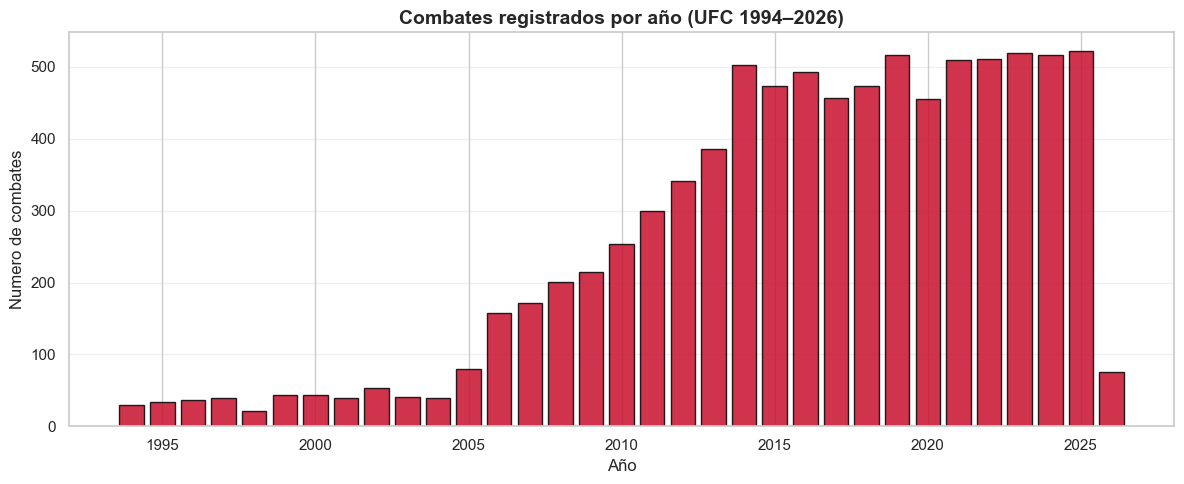

Año con mas combates: 2025 (522 peleas)
Año con menos combates: 1998 (21 peleas)


In [39]:
# Distribucion de combates por año - evolucion historica de la UFC
df_fights["Event_Year"] = pd.to_datetime(df_fights["Event_Date"]).dt.year
peleas_por_anio = df_fights["Event_Year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(peleas_por_anio.index, peleas_por_anio.values, color="#C8102E", edgecolor="black", alpha=0.85)
ax.set_title("Combates registrados por año (UFC 1994–2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Numero de combates")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Año con mas combates: {peleas_por_anio.idxmax()} ({peleas_por_anio.max()} peleas)")
print(f"Año con menos combates: {peleas_por_anio.idxmin()} ({peleas_por_anio.min()} peleas)")

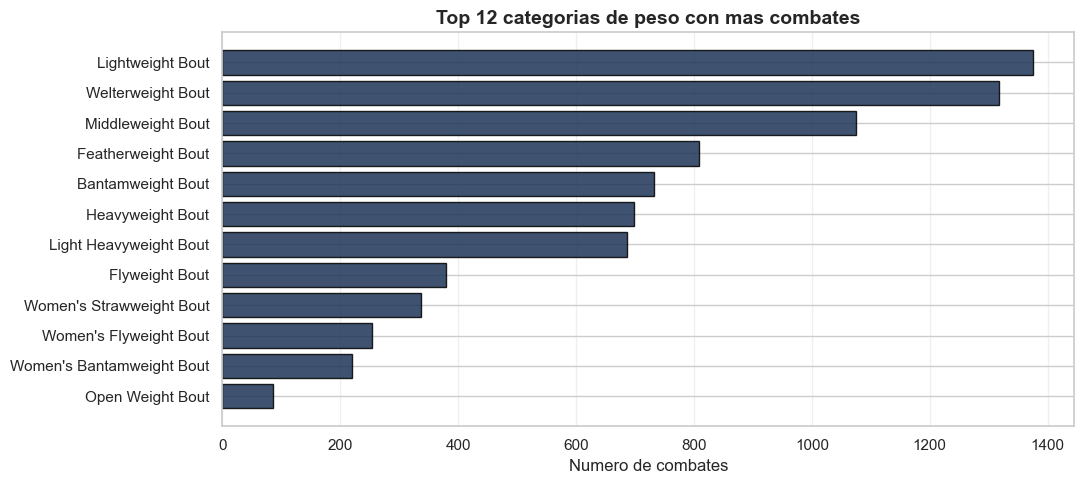

In [40]:
# Top categorias de peso - cuales son las mas representadas en el dataset
top_pesos = df_fights["Weight_Class"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_pesos.index[::-1], top_pesos.values[::-1], color="#1D3557", edgecolor="black", alpha=0.85)
ax.set_title("Top 12 categorias de peso con mas combates", fontsize=14, fontweight="bold")
ax.set_xlabel("Numero de combates")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

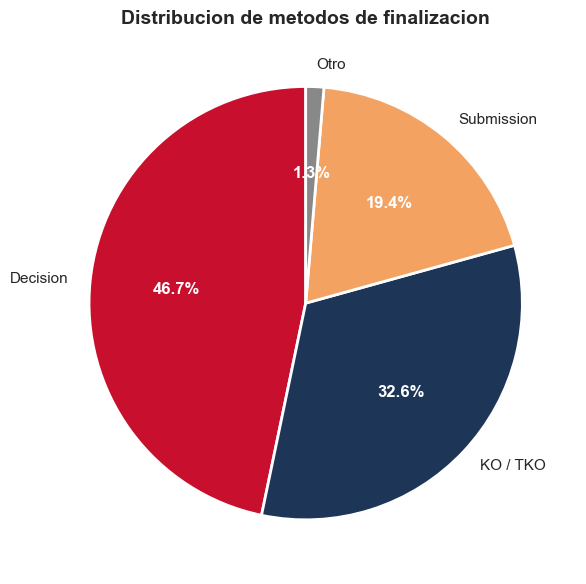


Conteo absoluto:
Method_Grouped
Decision      3996
KO / TKO      2785
Submission    1655
Otro           115
Name: count, dtype: int64


In [41]:
# Distribucion de metodos de finalizacion - conexion con el clustering
# Los grapplers tienden a ganar por Submission, los strikers por KO/TKO
# Agrupamos metodos similares para una vision mas clara
def agrupar_metodo(m):
    m = str(m).upper()
    if "KO" in m or "TKO" in m:
        return "KO / TKO"
    if "SUB" in m:
        return "Submission"
    if "DEC" in m:
        return "Decision"
    return "Otro"

df_fights["Method_Grouped"] = df_fights["Method"].apply(agrupar_metodo)
metodos = df_fights["Method_Grouped"].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))
colores = ["#C8102E", "#1D3557", "#F4A261", "#888888"]
wedges, texts, autotexts = ax.pie(
    metodos.values,
    labels=metodos.index,
    autopct="%1.1f%%",
    colors=colores[:len(metodos)],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
for t in autotexts:
    t.set_color("white")
    t.set_fontweight("bold")
ax.set_title("Distribucion de metodos de finalizacion", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nConteo absoluto:")
print(metodos)

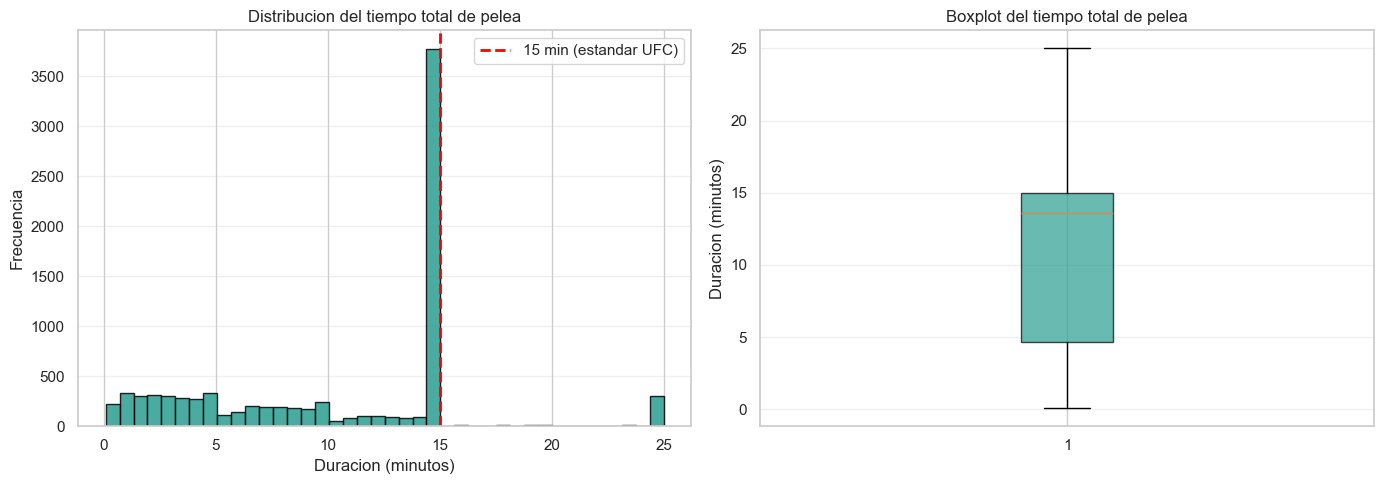

Duracion minima: 0.08 min
Duracion media:  10.59 min
Duracion maxima: 25.00 min

Observacion: la alta variabilidad (min 0.1 – max 25.0 min)
justifica normalizar las estadisticas por 15 min para comparar peleadores de forma justa.


In [42]:
# Distribucion del tiempo total de pelea - justifica la normalizacion por 15 min
# Las peleas duran entre segundos (KO rapido) y 25 min (5 rounds completos)
tiempo_min = df_fights["Total_Fight_Time_Sec"] / 60

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(tiempo_min, bins=40, color="#2A9D8F", edgecolor="black", alpha=0.85)
axes[0].axvline(15, color="red", linestyle="--", linewidth=2, label="15 min (estandar UFC)")
axes[0].set_title("Distribucion del tiempo total de pelea")
axes[0].set_xlabel("Duracion (minutos)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Boxplot
axes[1].boxplot(tiempo_min, vert=True, patch_artist=True,
                boxprops={"facecolor": "#2A9D8F", "alpha": 0.7})
axes[1].set_title("Boxplot del tiempo total de pelea")
axes[1].set_ylabel("Duracion (minutos)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Duracion minima: {tiempo_min.min():.2f} min")
print(f"Duracion media:  {tiempo_min.mean():.2f} min")
print(f"Duracion maxima: {tiempo_min.max():.2f} min")
print(f"\nObservacion: la alta variabilidad (min {tiempo_min.min():.1f} – max {tiempo_min.max():.1f} min)")
print("justifica normalizar las estadisticas por 15 min para comparar peleadores de forma justa.")

> **Interpretación:** las peleas duran entre segundos y 25 minutos, una variabilidad demasiado alta para comparar peleadores con promedios simples. Un peleador que gana por KO rápido conectaría pocos golpes en total, pero sería muy prolífico **por minuto**. Para evitar este sesgo se normalizan las estadísticas a una **tasa por cada 15 minutos peleados** (estándar oficial de UFC Stats), garantizando comparaciones justas entre todos los peleadores.

## 4. Construcción del DataFrame a nivel peleador

El dataset original está en formato **wide** (una fila por combate con prefijos `F1_` y `F2_`). Para el clustering necesitamos una fila **por peleador**, con sus estadísticas agregadas a lo largo de toda su carrera UFC.

**Proceso en tres pasos:**

1. **Apilar (stack):** convertir cada combate en dos filas, una por cada peleador participante, con sus respectivas estadísticas en columnas neutrales (`Sig_Landed`, `TD_Landed`, `Sub_Att`, `Ctrl_Sec`, `KD`, `Fight_Time_Sec`).

2. **Agregar por peleador:** agrupar por `Fighter` y **sumar** los totales acumulados de su carrera, además de contar el número de combates.

3. **Normalizar por 15 minutos** (estándar UFC Stats) aplicando la fórmula:

   $$\text{feature\_per15} = \frac{\text{total\_feature}}{\text{total\_time\_sec}} \times 900$$

   donde `900 = 15 min × 60 seg`. Esto entrega la **tasa promedio por cada 15 minutos peleados**, comparable entre todos los peleadores sin importar cuánto duraron sus combates.

Se incluyen también `Ctrl_Sec` y `KD` desde ahora aunque se usarán hasta el **análisis bonus**, para no recalcular el DataFrame después.

In [43]:
# PASO 1: Apilar F1 y F2 en formato largo
# Cada combate genera dos filas: una para cada peleador participante

# Vista del peleador 1
df_f1 = df_fights[[
    "Fighter_1", "Total_Fight_Time_Sec",
    "F1_Sig_Landed", "F1_TD_Landed", "F1_Sub_Att", "F1_Ctrl_Sec", "F1_KD",
]].rename(columns={
    "Fighter_1": "Fighter",
    "Total_Fight_Time_Sec": "Fight_Time_Sec",
    "F1_Sig_Landed": "Sig_Landed",
    "F1_TD_Landed": "TD_Landed",
    "F1_Sub_Att": "Sub_Att",
    "F1_Ctrl_Sec": "Ctrl_Sec",
    "F1_KD": "KD",
})

# Vista del peleador 2
df_f2 = df_fights[[
    "Fighter_2", "Total_Fight_Time_Sec",
    "F2_Sig_Landed", "F2_TD_Landed", "F2_Sub_Att", "F2_Ctrl_Sec", "F2_KD",
]].rename(columns={
    "Fighter_2": "Fighter",
    "Total_Fight_Time_Sec": "Fight_Time_Sec",
    "F2_Sig_Landed": "Sig_Landed",
    "F2_TD_Landed": "TD_Landed",
    "F2_Sub_Att": "Sub_Att",
    "F2_Ctrl_Sec": "Ctrl_Sec",
    "F2_KD": "KD",
})

# Concatenamos verticalmente: el resultado tiene 2x el numero de combates
df_stacked = pd.concat([df_f1, df_f2], ignore_index=True)

print(f"Combates originales: {len(df_fights):,}")
print(f"Filas tras apilar:   {len(df_stacked):,}  (= 2 x combates)")
print(f"\nPrimeras filas del DataFrame apilado:")
df_stacked.head()

Combates originales: 8,551
Filas tras apilar:   17,102  (= 2 x combates)

Primeras filas del DataFrame apilado:


,Fighter,Fight_Time_Sec,Sig_Landed,TD_Landed,Sub_Att,Ctrl_Sec,KD
0,Scott Morris,20,1,1,1,0,0
1,Patrick Smith,58,1,0,1,0,0
2,Royce Gracie,77,4,1,0,0,0
3,Royce Gracie,91,0,1,1,0,0
4,Patrick Smith,67,5,0,1,0,0


In [44]:
# PASO 2: Agregar por peleador - sumar totales de carrera y contar combates
df_fighters_agg = df_stacked.groupby("Fighter").agg(
    num_fights=("Fight_Time_Sec", "count"),
    total_time_sec=("Fight_Time_Sec", "sum"),
    total_sig=("Sig_Landed", "sum"),
    total_td=("TD_Landed", "sum"),
    total_sub=("Sub_Att", "sum"),
    total_ctrl=("Ctrl_Sec", "sum"),
    total_kd=("KD", "sum"),
).reset_index()

print(f"Peleadores unicos: {len(df_fighters_agg):,}")
print(f"\nDistribucion del numero de peleas por peleador:")
print(df_fighters_agg["num_fights"].describe().round(2))

Peleadores unicos: 2,647

Distribucion del numero de peleas por peleador:
count    2647.00
mean        6.46
std         6.12
min         1.00
25%         2.00
50%         4.00
75%         9.00
max        46.00
Name: num_fights, dtype: float64


In [45]:
# PASO 3: Normalizar por 15 minutos peleados (estandar UFC Stats)
# Formula: feature_per15 = total_feature / total_time_sec * 900   (900 seg = 15 min)
SEGUNDOS_15_MIN = 900

df_fighters_agg["avg_SIG_landed_per15"] = (
    df_fighters_agg["total_sig"] / df_fighters_agg["total_time_sec"] * SEGUNDOS_15_MIN
)
df_fighters_agg["avg_TD_landed_per15"] = (
    df_fighters_agg["total_td"] / df_fighters_agg["total_time_sec"] * SEGUNDOS_15_MIN
)
df_fighters_agg["avg_SUB_att_per15"] = (
    df_fighters_agg["total_sub"] / df_fighters_agg["total_time_sec"] * SEGUNDOS_15_MIN
)
# Features adicionales para el analisis bonus
df_fighters_agg["avg_CTRL_sec_per15"] = (
    df_fighters_agg["total_ctrl"] / df_fighters_agg["total_time_sec"] * SEGUNDOS_15_MIN
)
df_fighters_agg["avg_KD_per15"] = (
    df_fighters_agg["total_kd"] / df_fighters_agg["total_time_sec"] * SEGUNDOS_15_MIN
)

# Vista previa con las columnas relevantes
columnas_vista = [
    "Fighter", "num_fights",
    "avg_SIG_landed_per15", "avg_TD_landed_per15", "avg_SUB_att_per15",
    "avg_CTRL_sec_per15", "avg_KD_per15",
]
print("DataFrame a nivel peleador (primeros 10 registros, ordenados por numero de peleas):\n")
df_fighters_agg[columnas_vista].sort_values("num_fights", ascending=False).head(10).round(2)

DataFrame a nivel peleador (primeros 10 registros, ordenados por numero de peleas):



,Fighter,num_fights,avg_SIG_landed_per15,avg_TD_landed_per15,avg_SUB_att_per15,avg_CTRL_sec_per15,avg_KD_per15
1181,Jim Miller,46,43.82,1.50,1.70,188.62,0.20
145,Andrei Arlovski,42,57.99,0.33,0.18,70.47,0.37
711,Donald Cerrone,38,73.49,1.01,0.46,97.37,0.84
493,Clay Guida,37,40.97,2.76,0.57,332.65,0.21
1880,Neil Magny,37,51.01,2.17,0.27,192.34,0.07
420,Charles Oliveira,37,48.50,2.29,2.59,311.30,0.41
2025,Rafael Dos Anjos,36,52.22,1.95,0.57,235.18,0.20
1153,Jeremy Stephens,35,47.31,1.11,0.37,158.85,0.67
660,Demian Maia,33,27.06,2.49,0.99,341.22,0.04
689,Diego Sanchez,32,39.96,1.36,0.68,225.20,0.23


## 5. Filtro de muestra mínima: peleadores con ≥ 6 combates

Muchos peleadores tienen una o dos apariciones en UFC antes de ser despedidos, lo que produce estadísticas **poco representativas** del estilo real del atleta. Por ejemplo, un peleador que solo tuvo una pelea de 20 segundos con un KO temprano tendría tasas extremas no comparables al resto.

**Criterio adoptado: mantener solo peleadores con al menos 6 combates UFC.**

- Asegura suficiente muestra para que los promedios sean estables.
- Refleja una carrera UFC real (no participaciones aisladas).
- Mantiene una población amplia de peleadores para que el clustering tenga densidad estadística.

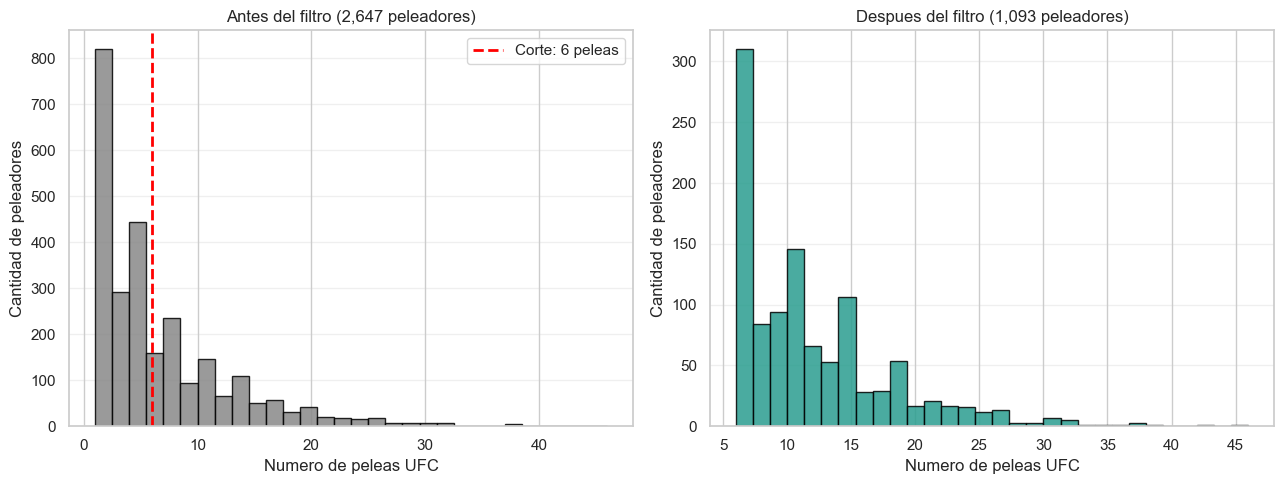

Peleadores antes del filtro:  2,647
Peleadores despues del filtro: 1,093
Reduccion: 58.7%

Promedio de peleas (filtrado): 12.0
Mediana de peleas (filtrado):  10


In [46]:
# Aplicar el filtro: solo peleadores con 6 o mas combates UFC
MIN_FIGHTS = 6
df_fighters = df_fighters_agg[df_fighters_agg["num_fights"] >= MIN_FIGHTS].copy().reset_index(drop=True)

# Comparacion visual: distribucion del numero de peleas antes y despues del filtro
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df_fighters_agg["num_fights"], bins=30, color="#888888", edgecolor="black", alpha=0.85)
axes[0].axvline(MIN_FIGHTS, color="red", linestyle="--", linewidth=2, label=f"Corte: {MIN_FIGHTS} peleas")
axes[0].set_title(f"Antes del filtro ({len(df_fighters_agg):,} peleadores)")
axes[0].set_xlabel("Numero de peleas UFC")
axes[0].set_ylabel("Cantidad de peleadores")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].hist(df_fighters["num_fights"], bins=30, color="#2A9D8F", edgecolor="black", alpha=0.85)
axes[1].set_title(f"Despues del filtro ({len(df_fighters):,} peleadores)")
axes[1].set_xlabel("Numero de peleas UFC")
axes[1].set_ylabel("Cantidad de peleadores")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Peleadores antes del filtro:  {len(df_fighters_agg):,}")
print(f"Peleadores despues del filtro: {len(df_fighters):,}")
print(f"Reduccion: {(1 - len(df_fighters)/len(df_fighters_agg))*100:.1f}%")
print(f"\nPromedio de peleas (filtrado): {df_fighters['num_fights'].mean():.1f}")
print(f"Mediana de peleas (filtrado):  {df_fighters['num_fights'].median():.0f}")

## 6. Análisis exploratorio de las features de clustering

Antes de aplicar K-Means, se analizan las tres variables principales del modelo ya normalizadas por 15 minutos. Este paso responde tres preguntas críticas para el éxito del agrupamiento:

1. **¿Cómo se distribuye cada variable?** Distribuciones muy sesgadas o con outliers pueden distorsionar los centroides de K-Means (que es sensible a valores extremos).
2. **¿Hay correlación entre las variables?** Si dos features están muy correlacionadas, una es redundante. Esperamos que `avg_TD` y `avg_SUB` tengan correlación positiva (ambas son señales de grappling), y que `avg_SIG` tenga correlación negativa con las otras dos (signo de un perfil táctico opuesto).
3. **¿Se ven agrupamientos naturales?** Los scatter plots pueden revelar visualmente si los datos forman "nubes" separadas, anticipando si el clustering tendrá sentido.

Las tres variables del análisis principal:

| Variable | Significado deportivo |
|---|---|
| `avg_SIG_landed_per15` | Golpes significativos conectados por cada 15 min — **señal de striker** |
| `avg_TD_landed_per15` | Derribos exitosos por cada 15 min — **señal de grappler/wrestler** |
| `avg_SUB_att_per15` | Intentos de sumisión por cada 15 min — **señal de grappler/jiu-jitsu** |

In [47]:
# Definir las 3 features del analisis principal
FEATURES_PRINCIPALES = ["avg_SIG_landed_per15", "avg_TD_landed_per15", "avg_SUB_att_per15"]

# Estadisticas descriptivas
print("Estadisticas descriptivas de las 3 features (normalizadas por 15 min):\n")
df_fighters[FEATURES_PRINCIPALES].describe().round(3)

Estadisticas descriptivas de las 3 features (normalizadas por 15 min):



,avg_SIG_landed_per15,avg_TD_landed_per15,avg_SUB_att_per15
count,1093.000,1093.000,1093.000
mean,52.977,1.553,0.585
std,18.470,1.244,0.621
min,5.425,0.000,0.000
25%,39.710,0.616,0.130
50%,51.740,1.251,0.417
75%,64.798,2.169,0.852
max,132.623,7.096,4.791


> **Interpretación:** los rangos son muy distintos — golpes (media 53, máx 133), derribos (media 1.5, máx 7) y sumisiones (media 0.6, máx 4.8). Sin escalar, K-Means se sesgaría hacia los golpes (variable de mayor magnitud) e ignoraría las otras dos. Esto justifica aplicar `StandardScaler` antes del entrenamiento.

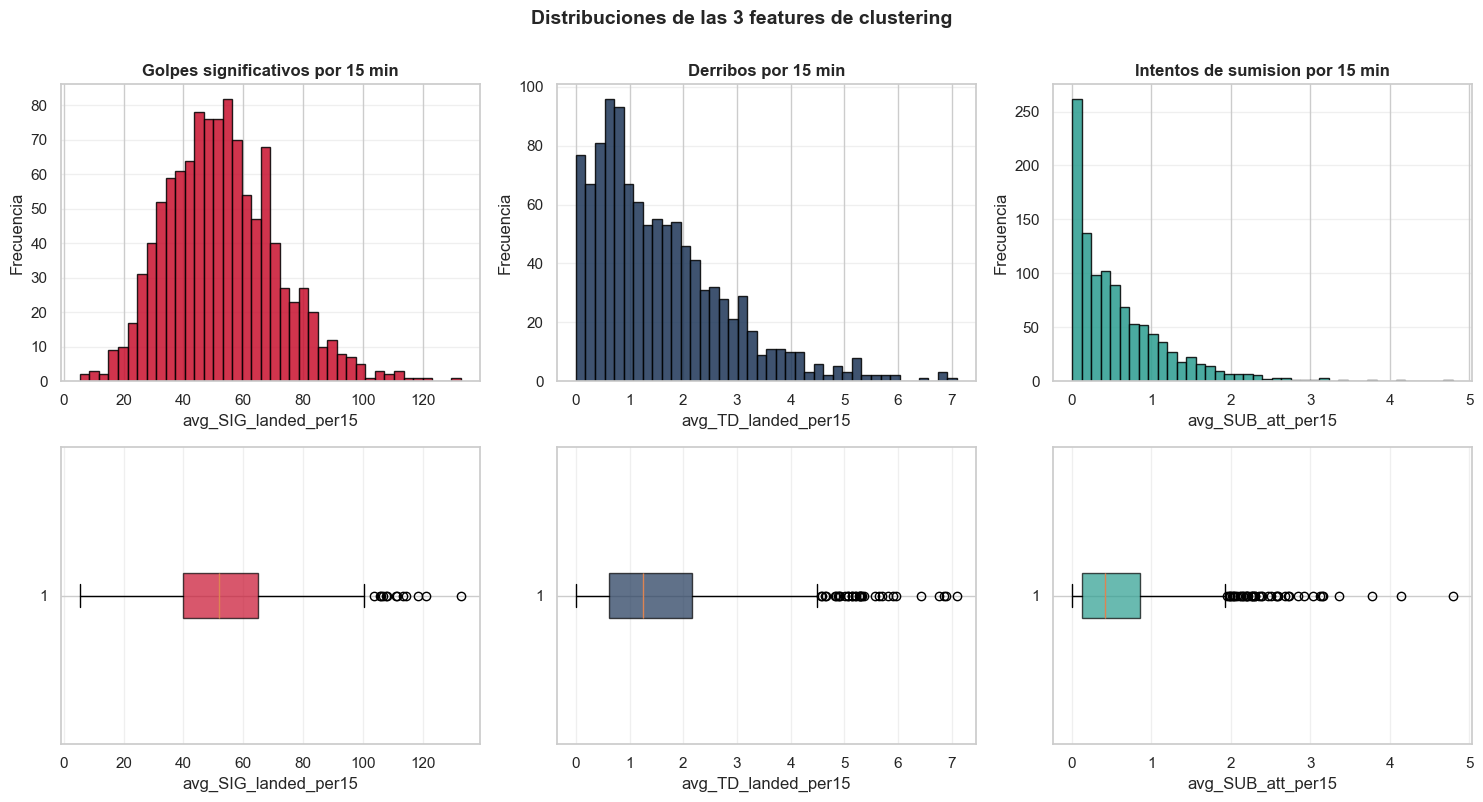

In [48]:
# Histogramas + boxplots de las 3 features para inspeccionar distribuciones y outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

colores_feat = {"avg_SIG_landed_per15": "#C8102E",
                "avg_TD_landed_per15":  "#1D3557",
                "avg_SUB_att_per15":    "#2A9D8F"}
nombres_feat = {"avg_SIG_landed_per15": "Golpes significativos por 15 min",
                "avg_TD_landed_per15":  "Derribos por 15 min",
                "avg_SUB_att_per15":    "Intentos de sumision por 15 min"}

for i, feat in enumerate(FEATURES_PRINCIPALES):
    # Histograma (fila superior)
    axes[0, i].hist(df_fighters[feat], bins=40, color=colores_feat[feat], edgecolor="black", alpha=0.85)
    axes[0, i].set_title(nombres_feat[feat], fontweight="bold")
    axes[0, i].set_xlabel(feat)
    axes[0, i].set_ylabel("Frecuencia")
    axes[0, i].grid(axis="y", alpha=0.3)

    # Boxplot (fila inferior)
    axes[1, i].boxplot(df_fighters[feat], vert=False, patch_artist=True,
                       boxprops={"facecolor": colores_feat[feat], "alpha": 0.7})
    axes[1, i].set_xlabel(feat)
    axes[1, i].grid(axis="x", alpha=0.3)

plt.suptitle("Distribuciones de las 3 features de clustering", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

> **Interpretación:** las tres distribuciones presentan **sesgo a la derecha**. Los golpes se distribuyen de forma más balanceada (la mayoría de peleadores golpea), mientras que derribos y sumisiones tienen muchos peleadores cercanos a cero y una cola de especialistas extremos visibles como outliers. Esto confirma que el grappling es una habilidad **especializada**, y anticipa que K-Means podrá separar fácilmente a esos especialistas del resto.

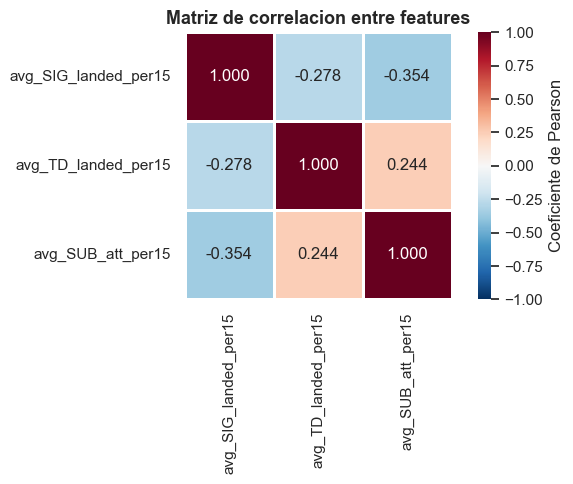


Interpretacion de las correlaciones:
  SIG_landed vs TD_landed: r = -0.278 (debil negativa)
  SIG_landed vs SUB_att: r = -0.354 (moderada negativa)
  TD_landed vs SUB_att: r = 0.244 (debil positiva)


In [49]:
# Matriz de correlacion entre las 3 features
corr_matrix = df_fighters[FEATURES_PRINCIPALES].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=1,
    cbar_kws={"label": "Coeficiente de Pearson"},
    ax=ax,
)
ax.set_title("Matriz de correlacion entre features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nInterpretacion de las correlaciones:")
for i, f1 in enumerate(FEATURES_PRINCIPALES):
    for f2 in FEATURES_PRINCIPALES[i+1:]:
        r = corr_matrix.loc[f1, f2]
        signo = "positiva" if r > 0 else "negativa"
        fuerza = "fuerte" if abs(r) > 0.5 else "moderada" if abs(r) > 0.3 else "debil"
        print(f"  {f1.replace('avg_','').replace('_per15','')} vs {f2.replace('avg_','').replace('_per15','')}: r = {r:.3f} ({fuerza} {signo})")

> **Interpretación:** las correlaciones son **moderadas y consistentes con la teoría táctica**. `TD` y `SUB` se correlacionan positivamente (ambas son habilidades de grappling), mientras que `SIG` correlaciona negativamente con las otras dos (estilos opuestos). Que ninguna correlación sea extrema (>|0.8|) confirma que las tres variables aportan información **complementaria**, no redundante.

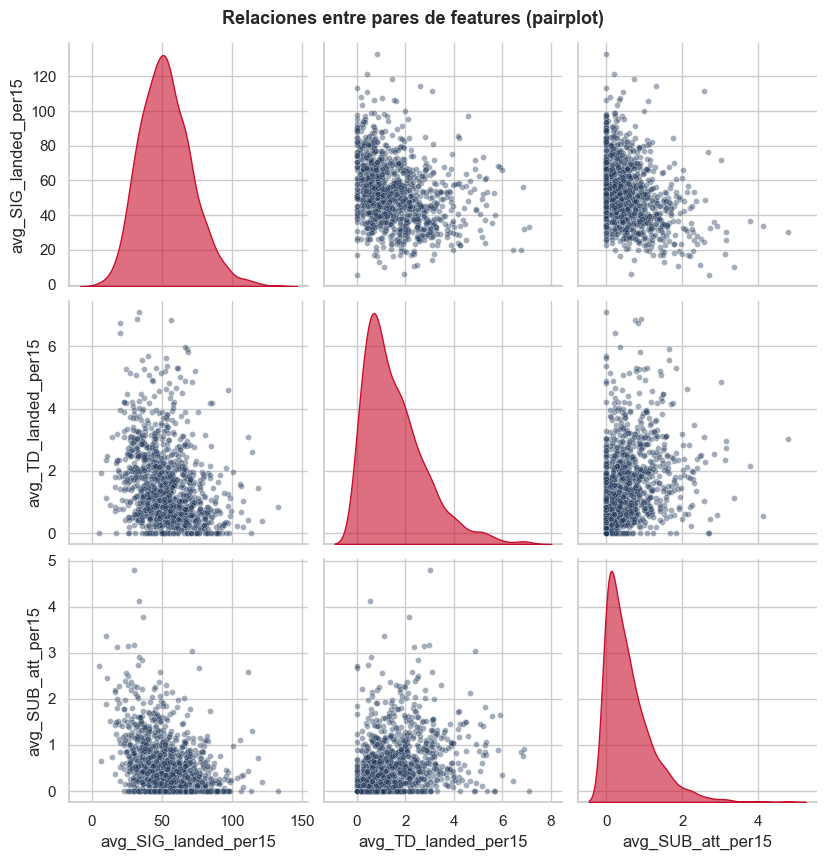

In [50]:
# Pairplot: scatter de todas las combinaciones de pares de features
# Permite ver visualmente si hay agrupamientos naturales antes del K-Means
g = sns.pairplot(
    df_fighters[FEATURES_PRINCIPALES],
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 18, "color": "#1D3557"},
    diag_kws={"color": "#C8102E", "fill": True, "alpha": 0.6},
    height=2.8,
)
g.fig.suptitle("Relaciones entre pares de features (pairplot)",
               fontsize=13, fontweight="bold", y=1.02)
plt.show()

> **Interpretación:** los scatter `SIG vs TD` y `SIG vs SUB` muestran una forma de **"L"**: peleadores con muchos golpes tienen pocos derribos/sumisiones, y viceversa. Esa estructura es la "firma" striker–grappler que el clustering debe detectar. Los puntos no forman una nube uniforme, lo que **valida que K-Means tiene un fenómeno real que agrupar** y no producirá clústeres artificiales.

## 7. Escalamiento de las features (StandardScaler)

K-Means es un algoritmo **basado en distancias euclidianas**. Cuando las variables están en escalas muy distintas, el algoritmo termina dominado por la variable de mayor magnitud y los clústeres se forman **principalmente con base en esa única variable**, ignorando el resto.

En nuestro caso:
- `avg_SIG_landed_per15` tiene valores ~50
- `avg_TD_landed_per15` tiene valores ~1.5
- `avg_SUB_att_per15` tiene valores ~0.6

Sin escalar, K-Means clasificaría peleadores casi por completo según los golpes. Para evitarlo aplicamos **estandarización Z-score**:

$$z = \frac{x - \mu}{\sigma}$$

Donde $\mu$ es la media y $\sigma$ la desviación estándar de la variable. El resultado: cada feature queda con **media 0 y desviación 1**, por lo que las tres tienen el mismo peso en el cálculo de distancias.

In [51]:
# Aplicar StandardScaler a las 3 features principales
X = df_fighters[FEATURES_PRINCIPALES].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame para facilitar la inspeccion
df_scaled = pd.DataFrame(X_scaled, columns=FEATURES_PRINCIPALES)

print("Estadisticas DESPUES del escalamiento (deben tener media ~0 y std ~1):\n")
df_scaled.describe().round(3)

Estadisticas DESPUES del escalamiento (deben tener media ~0 y std ~1):



,avg_SIG_landed_per15,avg_TD_landed_per15,avg_SUB_att_per15
count,1093.000,1093.000,1093.000
mean,-0.000,0.000,0.000
std,1.000,1.000,1.000
min,-2.576,-1.249,-0.942
25%,-0.719,-0.753,-0.733
50%,-0.067,-0.242,-0.270
75%,0.640,0.496,0.431
max,4.314,4.460,6.777


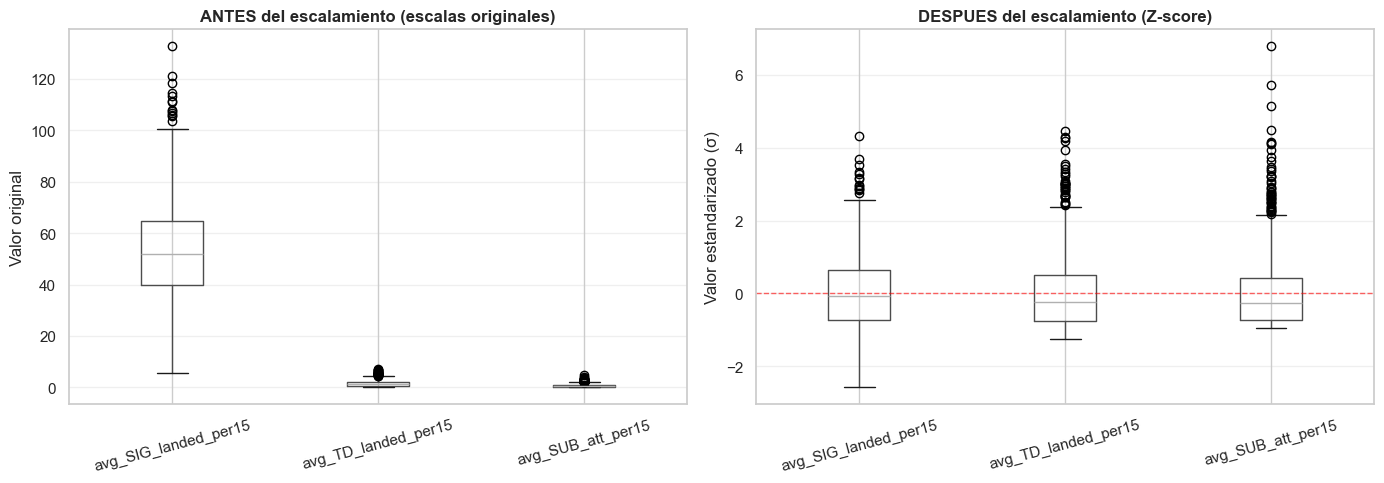

Las 3 variables ahora estan en la misma escala y K-Means puede tratarlas con igual peso.


In [52]:
# Comparacion visual: boxplots antes y despues del escalamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes (escalas originales)
df_fighters[FEATURES_PRINCIPALES].boxplot(ax=axes[0])
axes[0].set_title("ANTES del escalamiento (escalas originales)", fontweight="bold")
axes[0].set_ylabel("Valor original")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

# Despues (escala estandarizada)
df_scaled.boxplot(ax=axes[1])
axes[1].set_title("DESPUES del escalamiento (Z-score)", fontweight="bold")
axes[1].set_ylabel("Valor estandarizado (σ)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1, alpha=0.6)

plt.tight_layout()
plt.show()

print("Las 3 variables ahora estan en la misma escala y K-Means puede tratarlas con igual peso.")

> **Interpretación:** después del escalamiento, las tres variables se centran en cero y comparten la misma escala de dispersión. En el boxplot izquierdo los derribos y sumisiones aparecen "aplastados" porque están en escala absoluta; en el derecho se ven proporcionalmente comparables a los golpes. Los datos están listos para alimentar K-Means.

## 8. Selección del número óptimo de clústeres (K)

K-Means requiere especificar **a priori** el número de grupos. Para tomar esta decisión se utilizan dos métricas complementarias:

### Método del Codo (Elbow Method)

Se entrena K-Means con distintos valores de `K` y se mide la **inercia** (también llamada *within-cluster sum of squares*):

$$\text{Inercia} = \sum_{i=1}^{n} \min_{c \in C} \| x_i - c \|^2$$

La inercia siempre disminuye al aumentar `K` (más clústeres = puntos más cerca de sus centroides). Buscamos el **"codo"** de la curva: el valor de `K` donde la mejora marginal se aplana.

### Silhouette Score

Para cada punto se calcula:

$$s = \frac{b - a}{\max(a, b)}$$

donde `a` es la distancia media al resto de su clúster (cohesión) y `b` la distancia media al clúster vecino más cercano (separación). El score global es el promedio; va de **-1 a 1**, y valores **más altos indican mejor separación**.

Se evalúan ambas métricas para `K = 2..10` y se elige el `K` que **balancee** un codo visible con un silhouette razonablemente alto, manteniendo interpretabilidad deportiva.

In [53]:
# Calcular inercia y silhouette score para K = 2 hasta 10
K_range = range(2, 11)
inercias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"K={k:2d}  |  Inercia = {km.inertia_:8.2f}  |  Silhouette = {silhouettes[-1]:.4f}")

K= 2  |  Inercia =  2140.69  |  Silhouette = 0.3470
K= 3  |  Inercia =  1693.59  |  Silhouette = 0.3486
K= 4  |  Inercia =  1303.40  |  Silhouette = 0.2991
K= 5  |  Inercia =  1164.95  |  Silhouette = 0.2738
K= 6  |  Inercia =  1050.17  |  Silhouette = 0.2610
K= 7  |  Inercia =   965.51  |  Silhouette = 0.2650
K= 8  |  Inercia =   867.10  |  Silhouette = 0.2570
K= 9  |  Inercia =   806.39  |  Silhouette = 0.2536
K=10  |  Inercia =   756.25  |  Silhouette = 0.2613


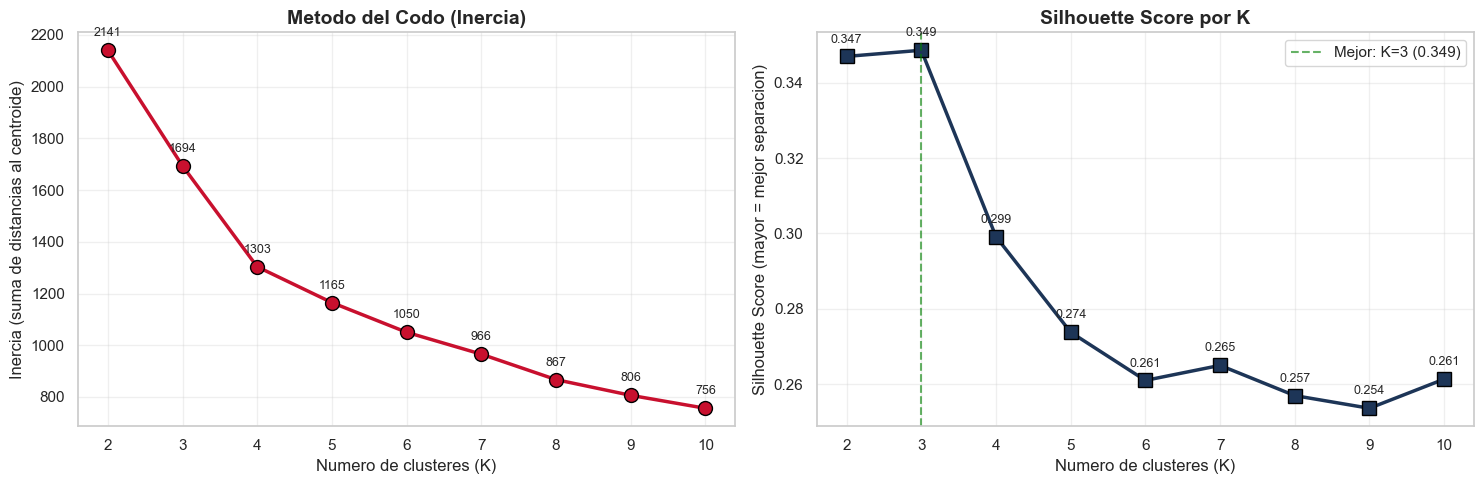


K con mejor Silhouette Score: K = 3  (score = 0.3486)


In [54]:
# Visualizacion del Metodo del Codo y Silhouette Score lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Metodo del Codo ---
axes[0].plot(list(K_range), inercias, marker="o", linewidth=2.5,
             markersize=10, color="#C8102E", markeredgecolor="black")
axes[0].set_title("Metodo del Codo (Inercia)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Numero de clusteres (K)")
axes[0].set_ylabel("Inercia (suma de distancias al centroide)")
axes[0].set_xticks(list(K_range))
axes[0].grid(alpha=0.3)
for k, val in zip(K_range, inercias):
    axes[0].annotate(f"{val:.0f}", (k, val), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9)

# --- Silhouette Score ---
axes[1].plot(list(K_range), silhouettes, marker="s", linewidth=2.5,
             markersize=10, color="#1D3557", markeredgecolor="black")
axes[1].set_title("Silhouette Score por K", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Numero de clusteres (K)")
axes[1].set_ylabel("Silhouette Score (mayor = mejor separacion)")
axes[1].set_xticks(list(K_range))
axes[1].grid(alpha=0.3)
# Resaltar el K con mejor silhouette
k_mejor_sil = list(K_range)[np.argmax(silhouettes)]
sil_max = max(silhouettes)
axes[1].axvline(k_mejor_sil, color="green", linestyle="--", alpha=0.6,
                label=f"Mejor: K={k_mejor_sil} ({sil_max:.3f})")
axes[1].legend()
for k, val in zip(K_range, silhouettes):
    axes[1].annotate(f"{val:.3f}", (k, val), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nK con mejor Silhouette Score: K = {k_mejor_sil}  (score = {sil_max:.4f})")

> **Decisión: K = 3.**
>
> El **Silhouette Score** alcanza su máximo en K=3 (≈ 0.349), métrica objetiva que indica la mejor separación entre clústeres. El **Método del Codo** muestra que después de K=3 la reducción de inercia se desacelera notablemente. Además, K=3 entrega una **taxonomía deportivamente interpretable** (strikers / grapplers / híbridos), mientras que K=2 sería trivial y K=4+ fragmenta los grupos sin ganar separación. Se entrena el modelo definitivo con **K = 3**.

## 9. Entrenamiento del modelo K-Means final

Se entrena el modelo definitivo con `K = 3` sobre los datos escalados. Parámetros clave:

- **`n_clusters = 3`** — el K elegido en la sección anterior.
- **`random_state = 42`** — semilla fija para que el resultado sea **reproducible** (K-Means inicializa los centroides al azar).
- **`n_init = 10`** — el algoritmo se ejecuta 10 veces con diferentes inicializaciones y se queda con la solución de menor inercia. Aumenta la robustez del resultado.

Después del entrenamiento se obtienen:
- La **asignación de clúster** para cada peleador (etiqueta 0, 1 o 2).
- Los **centroides** (punto promedio que define cada clúster). Se reportan en su **escala original** (no estandarizada) para facilitar la interpretación deportiva.

In [55]:
# Entrenamiento del K-Means definitivo
K_FINAL = 3
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_scaled)

# Asignar la etiqueta de cluster a cada peleador
df_fighters["Cluster"] = kmeans.labels_

# Recuperar los centroides en la ESCALA ORIGINAL (mas interpretables que en Z-score)
centroides_originales = scaler.inverse_transform(kmeans.cluster_centers_)
df_centroides = pd.DataFrame(centroides_originales, columns=FEATURES_PRINCIPALES)
df_centroides.index.name = "Cluster"

print("Centroides (en escala original, valores por 15 min de pelea):\n")
df_centroides.round(2)

Centroides (en escala original, valores por 15 min de pelea):



,avg_SIG_landed_per15,avg_TD_landed_per15,avg_SUB_att_per15
Cluster,,,
0,60.84,0.87,0.31
1,37.04,1.61,1.66
2,43.89,3.14,0.59


In [56]:
# Distribucion de peleadores por cluster
conteo = df_fighters["Cluster"].value_counts().sort_index()
porcentaje = (conteo / len(df_fighters) * 100).round(1)

resumen = pd.DataFrame({
    "Cantidad de peleadores": conteo,
    "Porcentaje (%)": porcentaje,
})
print("Distribucion de peleadores por cluster:\n")
print(resumen)
print(f"\nInercia final del modelo: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, kmeans.labels_):.4f}")

Distribucion de peleadores por cluster:

         Cantidad de peleadores  Porcentaje (%)
Cluster                                        
0                           653            59.7
1                           166            15.2
2                           274            25.1

Inercia final del modelo: 1693.59
Silhouette Score: 0.3486


### Interpretación inicial de los clústeres

Los centroides revelan **tres perfiles tácticos claramente diferenciados**:

| Clúster | SIG / 15 min | TD / 15 min | SUB / 15 min | % peleadores | Perfil táctico |
|:---:|:---:|:---:|:---:|:---:|:---|
| **0** | **60.8** ⬆ | 0.87 | 0.31 | **59.7 %** | **Strikers puros** — golpean a tasa muy alta y casi no llevan al suelo |
| **1** | 37.0 | 1.61 | **1.66** ⬆ | 15.2 % | **Grapplers ofensivos (perfil de sumisión)** — tasa de intentos de sumisión más alta del dataset (estilo jiu-jitsu) |
| **2** | 43.9 | **3.14** ⬆⬆ | 0.59 | 25.1 % | **Wrestlers / grapplers posicionales** — derriban masivamente, buscan control sobre sumisión |

**Hallazgos clave:**

1. **El striking es el "lenguaje común" del MMA moderno:** casi el 60 % de los peleadores pertenece al grupo de strikers puros, lo que coincide con la evolución del deporte hacia el striking de alto volumen.
2. **El grappling se divide en dos sub-estilos opuestos**, lo cual es un hallazgo no trivial: el algoritmo distinguió por sí solo entre la escuela del **jiu-jitsu** (busca finalizar con sumisión) y la del **wrestling** (busca controlar y dominar).
3. **Las proporciones son consistentes con el deporte real**, donde los especialistas en grappling son minoría frente a la mayoría de strikers.

Con esta taxonomía base se procede a las visualizaciones del clustering.

## 10. Visualizaciones del clustering

Se presentan cuatro visualizaciones complementarias del resultado del K-Means:

1. **Scatter 3D** — los tres ejes son las tres features del modelo (`SIG`, `TD`, `SUB`); cada punto es un peleador coloreado por clúster, con los centroides marcados.
2. **Proyección PCA 2D** — reduce las 3 dimensiones a 2 mediante Análisis de Componentes Principales, conservando la mayor varianza posible. Ideal para una vista limpia en el documento final.
3. **Radar chart de centroides** — visualiza el "perfil" de cada clúster en una única figura, útil para la presentación.
4. **Boxplots por clúster** — confirma que la separación entre grupos es real para cada variable individualmente.

Se utilizan colores consistentes en todas las visualizaciones:
- 🔴 **Rojo:** Strikers puros (Clúster 0)
- 🟢 **Verde:** Grapplers ofensivos (perfil de sumisión) (Clúster 1)
- 🔵 **Azul:** Wrestlers / grapplers posicionales (Clúster 2)

In [57]:
# Diccionarios de nombres y colores consistentes en todas las visualizaciones
NOMBRES_CLUSTER = {
    0: "Strikers puros",
    1: "Grapplers ofensivos (perfil de sumision)",
    2: "Wrestlers / Grapplers posicionales",
}
COLORES_CLUSTER = {
    0: "#C8102E",  # Rojo
    1: "#2A9D8F",  # Verde
    2: "#1D3557",  # Azul
}

# Guardar el nombre del cluster como columna nueva
df_fighters["Cluster_Nombre"] = df_fighters["Cluster"].map(NOMBRES_CLUSTER)

# Vista previa
df_fighters[["Fighter", "num_fights", "Cluster", "Cluster_Nombre"] + FEATURES_PRINCIPALES].head(8).round(2)

,Fighter,num_fights,Cluster,Cluster_Nombre,avg_SIG_landed_per15,avg_TD_landed_per15,avg_SUB_att_per15
0,Aaron Riley,9,0,Strikers puros,49.39,1.26,0.16
1,Aaron Simpson,11,2,Wrestlers / Grapplers posicionales,53.74,3.79,0.47
2,Abdul Razak Alhassan,14,0,Strikers puros,53.72,0.85,0.17
3,Abel Trujillo,11,2,Wrestlers / Grapplers posicionales,39.69,2.18,0.44
4,Abus Magomedov,7,2,Wrestlers / Grapplers posicionales,46.01,2.61,0.40
5,Adam Fugitt,6,0,Strikers puros,73.15,1.63,0.00
6,Adrian Yanez,9,0,Strikers puros,92.83,0.00,0.00
7,Adriano Martins,7,0,Strikers puros,26.91,1.04,0.52


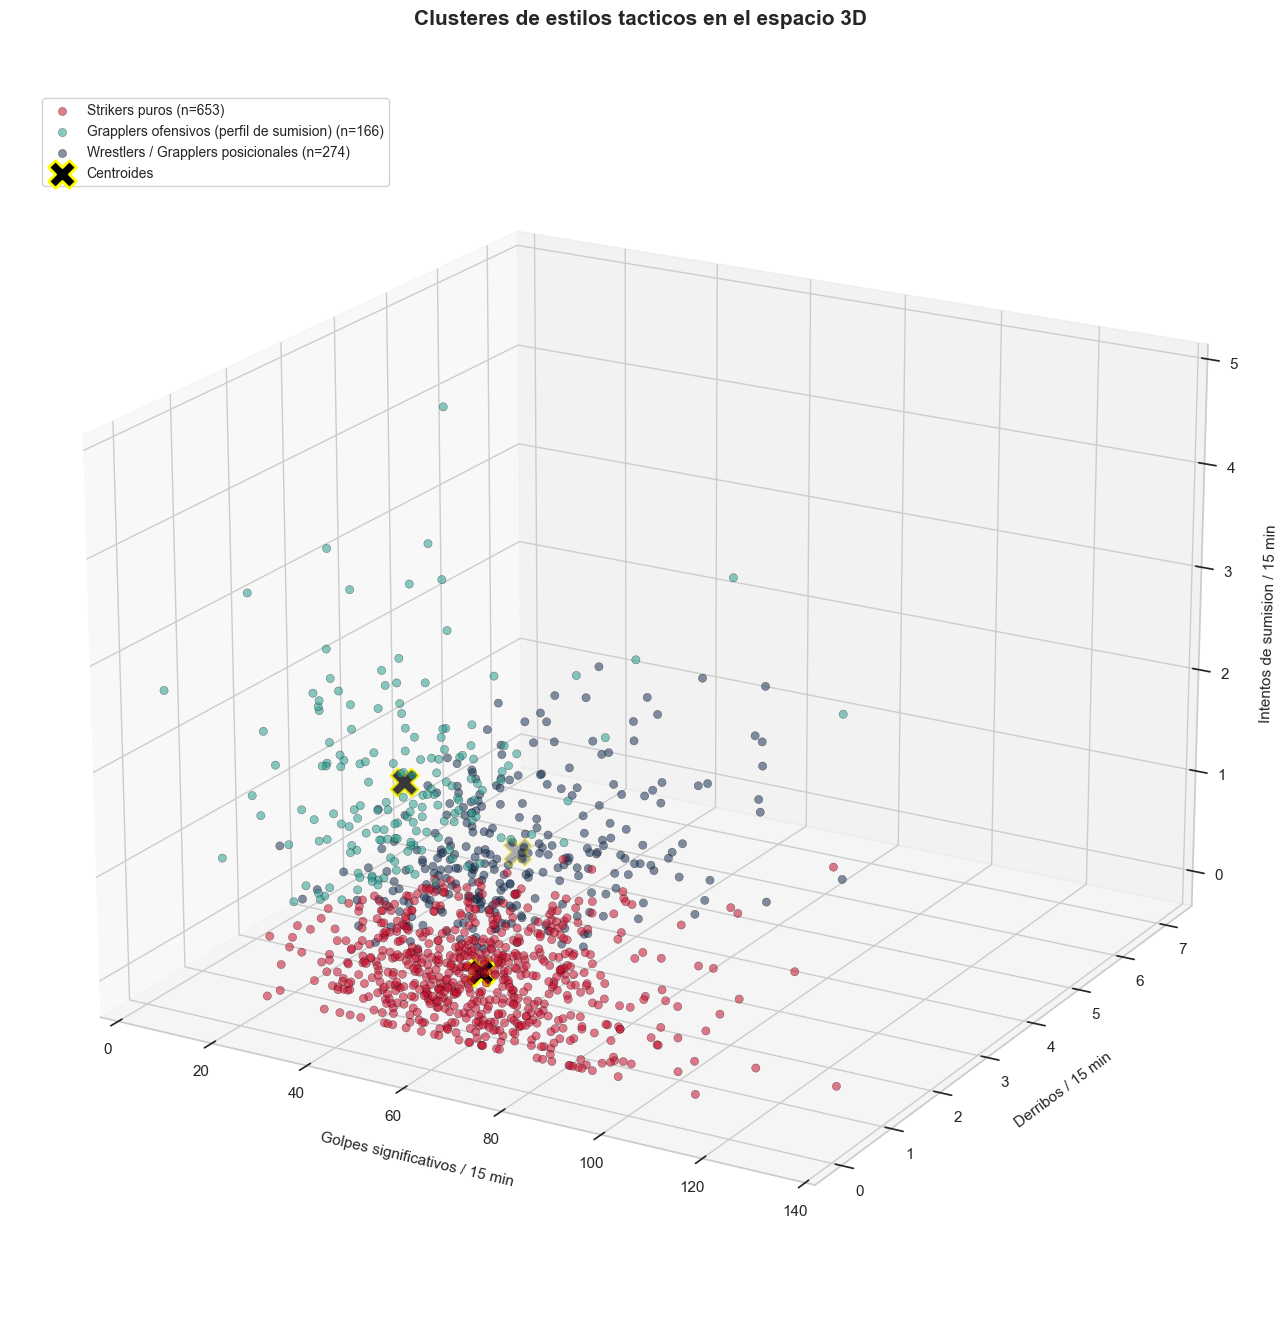

In [58]:
# Visualizacion 1: Scatter 3D con los 3 features y centroides marcados
fig = plt.figure(figsize=(14, 15))
ax = fig.add_subplot(111, projection="3d")

for c in sorted(df_fighters["Cluster"].unique()):
    sub = df_fighters[df_fighters["Cluster"] == c]
    ax.scatter(
        sub["avg_SIG_landed_per15"],
        sub["avg_TD_landed_per15"],
        sub["avg_SUB_att_per15"],
        c=COLORES_CLUSTER[c],
        label=f"{NOMBRES_CLUSTER[c]} (n={len(sub)})",
        alpha=0.55,
        s=35,
        edgecolors="black",
        linewidths=0.3,
    )

# Marcar los centroides como X grandes con borde amarillo
ax.scatter(
    centroides_originales[:, 0],
    centroides_originales[:, 1],
    centroides_originales[:, 2],
    c="black",
    marker="X",
    s=400,
    edgecolors="yellow",
    linewidths=2,
    label="Centroides",
)

ax.set_xlabel("Golpes significativos / 15 min", fontsize=11, labelpad=12)
ax.set_ylabel("Derribos / 15 min", fontsize=11, labelpad=12)
ax.set_zlabel("Intentos de sumision / 15 min", fontsize=11, labelpad=10)
ax.set_title("Clusteres de estilos tacticos en el espacio 3D",
             fontsize=15, fontweight="bold", pad=30)
ax.legend(loc="upper left", fontsize=10, framealpha=0.9, bbox_to_anchor=(0.02, 0.98))

# Ajustar el angulo de la vista para que se vean los tres ejes claramente
ax.view_init(elev=20, azim=-60)

# Margenes manuales para evitar que el titulo o ejes se corten
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)
plt.show()

> **Interpretación (Scatter 3D):** se observan tres nubes claramente separadas en el espacio tridimensional. Los **strikers (rojo)** se concentran en el eje de golpes y aplastados en los ejes de derribos y sumisiones. Los **wrestlers (azul)** se alzan en el eje de derribos, mientras que los **especialistas en sumisión (verde)** sobresalen en el eje de intentos de sumisión. Los centroides (X negras) representan el "peleador promedio" de cada arquetipo táctico.

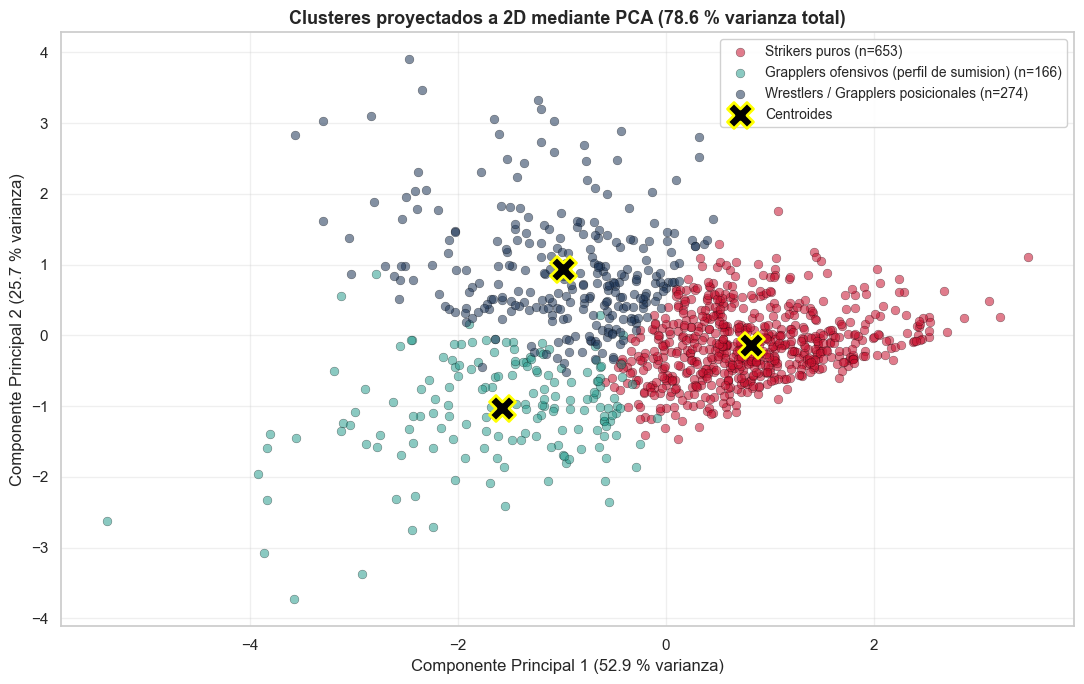

Varianza explicada por PC1: 52.86 %
Varianza explicada por PC2: 25.71 %
Varianza total conservada en la proyeccion 2D: 78.58 %


In [59]:
# Visualizacion 2: Proyeccion PCA 2D
# PCA reduce las 3 features a 2 componentes principales que conservan la mayor varianza
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Tambien proyectamos los centroides al espacio PCA
centroides_pca = pca.transform(kmeans.cluster_centers_)

# Porcentaje de varianza explicada por cada componente
varianza = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(11, 7))
for c in sorted(df_fighters["Cluster"].unique()):
    mask = df_fighters["Cluster"] == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=COLORES_CLUSTER[c],
        label=f"{NOMBRES_CLUSTER[c]} (n={mask.sum()})",
        alpha=0.55, s=40, edgecolors="black", linewidths=0.3,
    )

# Centroides en el espacio PCA
ax.scatter(
    centroides_pca[:, 0], centroides_pca[:, 1],
    c="black", marker="X", s=350,
    edgecolors="yellow", linewidths=2, label="Centroides",
)

ax.set_xlabel(f"Componente Principal 1 ({varianza[0]:.1f} % varianza)", fontsize=12)
ax.set_ylabel(f"Componente Principal 2 ({varianza[1]:.1f} % varianza)", fontsize=12)
ax.set_title(f"Clusteres proyectados a 2D mediante PCA "
             f"({varianza.sum():.1f} % varianza total)",
             fontsize=13, fontweight="bold")
ax.legend(loc="best", fontsize=10, framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Varianza explicada por PC1: {varianza[0]:.2f} %")
print(f"Varianza explicada por PC2: {varianza[1]:.2f} %")
print(f"Varianza total conservada en la proyeccion 2D: {varianza.sum():.2f} %")

> **Interpretación (PCA 2D):** la proyección bidimensional conserva la mayor parte de la varianza original y muestra los tres clústeres bien delimitados, con poca superposición en los bordes. Esta vista es la versión "limpia" del clustering: los strikers ocupan una región amplia, mientras que sumisores y wrestlers se ubican en zonas distintas del plano. Es la gráfica idónea para incluir en el documento final y la presentación.

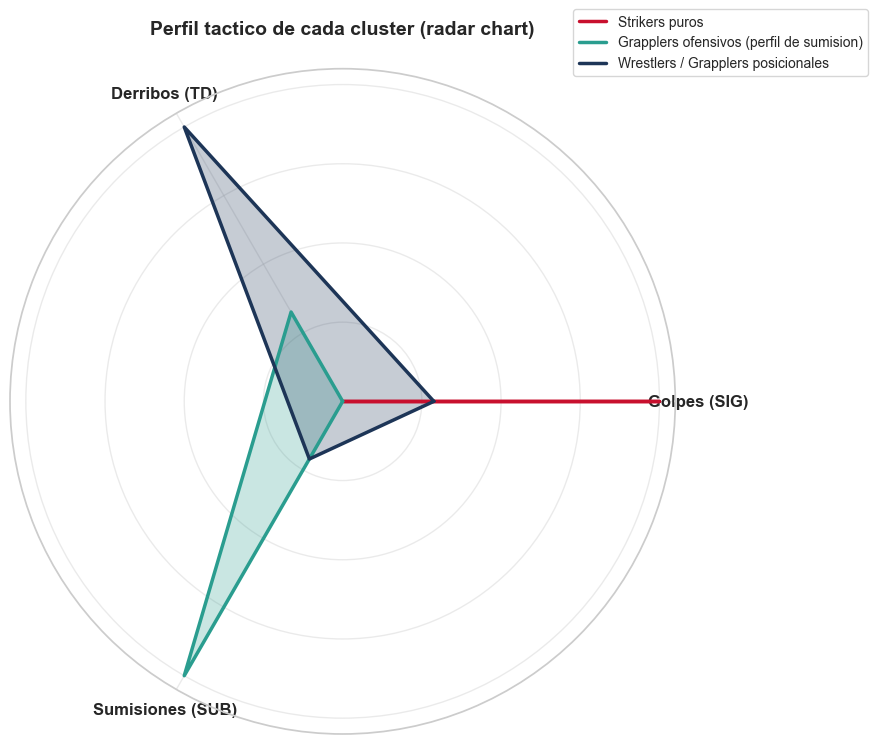

In [60]:
# Visualizacion 3: Radar chart de los centroides
# Compara el "perfil" de los 3 clusteres en una sola figura
from math import pi

# Normalizar los centroides al rango 0-1 para que el radar sea legible
cent_min = centroides_originales.min(axis=0)
cent_max = centroides_originales.max(axis=0)
centroides_norm = (centroides_originales - cent_min) / (cent_max - cent_min)

# Etiquetas en español para los ejes del radar
etiquetas = ["Golpes (SIG)", "Derribos (TD)", "Sumisiones (SUB)"]
N = len(etiquetas)

# Calcular angulos del poligono
angulos = [n / float(N) * 2 * pi for n in range(N)]
angulos += angulos[:1]  # cerrar el poligono

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for c in sorted(df_fighters["Cluster"].unique()):
    valores = centroides_norm[c].tolist()
    valores += valores[:1]  # cerrar el poligono
    ax.plot(angulos, valores, color=COLORES_CLUSTER[c], linewidth=2.5,
            label=NOMBRES_CLUSTER[c])
    ax.fill(angulos, valores, color=COLORES_CLUSTER[c], alpha=0.25)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(etiquetas, fontsize=12, fontweight="bold")
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["", "", "", ""])  # ocultamos los valores radiales (la forma es lo que importa)
ax.set_ylim(0, 1.05)
ax.set_title("Perfil tactico de cada cluster (radar chart)",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

> **Interpretación (Radar chart):** cada polígono representa el "ADN táctico" de un clúster. El **rojo (strikers)** se extiende casi únicamente sobre el eje de golpes; el **verde (sumisores)** alcanza su pico en el eje de sumisiones; y el **azul (wrestlers)** se proyecta sobre el eje de derribos. Las tres figuras son visualmente **disjuntas**, lo que confirma que los clústeres representan estilos tácticos genuinamente distintos y no variaciones de un mismo perfil.

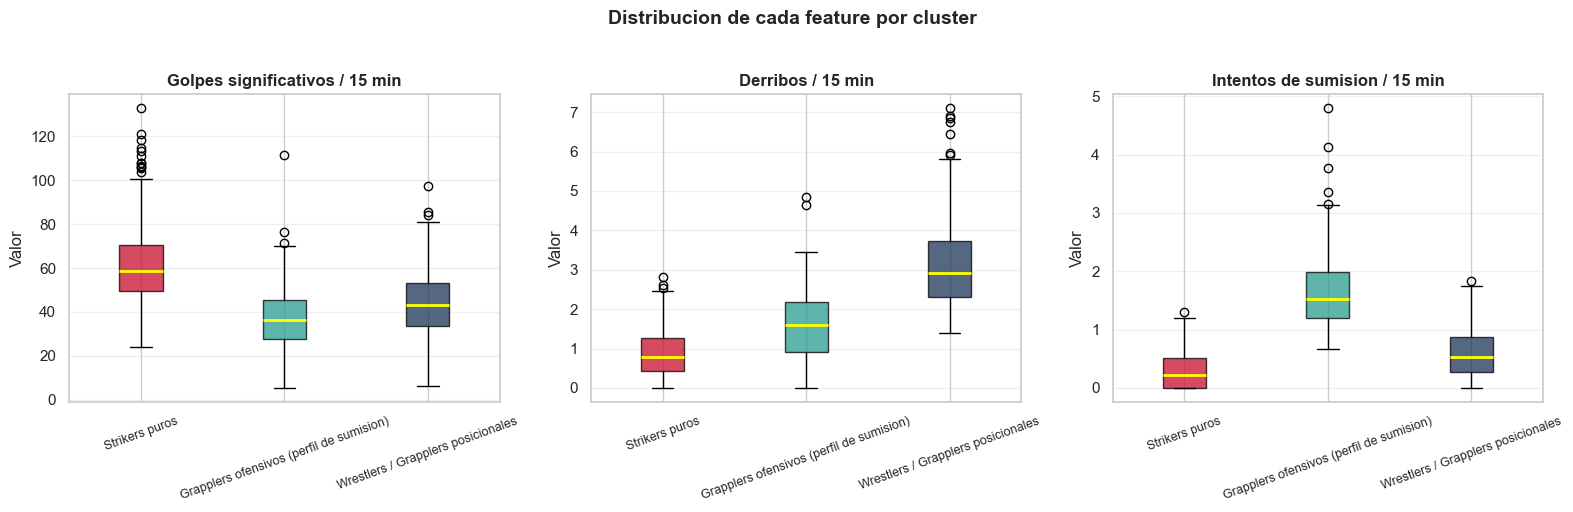

In [61]:
# Visualizacion 4: Boxplots de cada feature segmentados por cluster
# Validacion visual de que la separacion entre grupos es real para CADA variable
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

nombres_legibles = {
    "avg_SIG_landed_per15": "Golpes significativos / 15 min",
    "avg_TD_landed_per15":  "Derribos / 15 min",
    "avg_SUB_att_per15":    "Intentos de sumision / 15 min",
}

for i, feat in enumerate(FEATURES_PRINCIPALES):
    datos_por_cluster = [df_fighters[df_fighters["Cluster"] == c][feat].values
                         for c in sorted(df_fighters["Cluster"].unique())]
    nombres = [NOMBRES_CLUSTER[c] for c in sorted(df_fighters["Cluster"].unique())]
    colores = [COLORES_CLUSTER[c] for c in sorted(df_fighters["Cluster"].unique())]

    bp = axes[i].boxplot(datos_por_cluster, labels=nombres, patch_artist=True,
                          medianprops={"color": "yellow", "linewidth": 2})
    for patch, color in zip(bp["boxes"], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    axes[i].set_title(nombres_legibles[feat], fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Valor")
    axes[i].tick_params(axis="x", rotation=20, labelsize=9)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Distribucion de cada feature por cluster",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

> **Cómo leer estas gráficas (mini-guía):**
> - Cada **caja** contiene el 50% central de los peleadores de ese clúster; la **línea amarilla** es la mediana (el peleador "típico" del grupo).
> - Los **puntos sueltos** por encima son outliers: peleadores excepcionales que llevan al extremo el estilo de su clúster.
> - En cada panel, busca **qué caja está más arriba**: esa identifica al clúster especialista en esa habilidad. Las cajas deben verse "escalonadas" (no traslapadas) para confirmar que la separación entre grupos es real.

> **Interpretación (Boxplots por clúster):** confirman que la separación es **real para cada variable individualmente**, no solo en el espacio combinado. En cada gráfica, el clúster asociado a esa habilidad muestra una caja claramente elevada respecto a los otros dos: los strikers dominan en golpes, los sumisores en intentos de sumisión y los wrestlers en derribos. La presencia de outliers indica peleadores excepcionales que llevan al extremo el estilo de su clúster (potenciales casos icónicos como Khabib o Demian Maia).

## 11. Interpretación y nombramiento formal de los clústeres

Con el clustering entrenado y validado visualmente, se procede a:

1. **Identificar al peleador "más representativo" de cada clúster** — aquel cuyas estadísticas se encuentran más cerca del centroide en el espacio escalado. Estos peleadores son el "rostro" táctico de cada arquetipo y resultan útiles para comunicar los hallazgos.
2. **Generar la tabla resumen final** de la taxonomía descubierta, integrando: nombre del clúster, tamaño relativo, valores promedio (centroides) y los peleadores arquetípicos.

El cálculo de "representatividad" usa la **distancia euclidiana** entre el vector de features escaladas de cada peleador y el centroide de su clúster. Cuanto menor sea la distancia, más se parece el peleador al "promedio" del grupo.

In [69]:
# Calcular la distancia de cada peleador a su centroide (espacio escalado)
distancias = np.linalg.norm(
    X_scaled - kmeans.cluster_centers_[kmeans.labels_],
    axis=1,
)
df_fighters["Distancia_Centroide"] = distancias

# Construir tabla con top 5 representativos de cada cluster
filas_top = []
for c in sorted(df_fighters["Cluster"].unique()):
    top5 = (df_fighters[df_fighters["Cluster"] == c]
            .nsmallest(5, "Distancia_Centroide"))
    for _, r in top5.iterrows():
        filas_top.append({
            "Cluster": c,
            "Perfil tactico": NOMBRES_CLUSTER[c],
            "Peleador": r["Fighter"],
            "N peleas": r["num_fights"],
            "SIG/15": round(r["avg_SIG_landed_per15"], 2),
            "TD/15":  round(r["avg_TD_landed_per15"],  2),
            "SUB/15": round(r["avg_SUB_att_per15"],  2),
            "Distancia": round(r["Distancia_Centroide"], 3),
        })

df_top = pd.DataFrame(filas_top)

# Colorear cada bloque de cluster con su color caracteristico
def color_cluster(val, c):
    colores_fondo = {0: "#fdecee", 1: "#e6f4f1", 2: "#e8edf3"}
    return f"background-color: {colores_fondo[c]};"

def aplicar_color_fila(row):
    c = row["Cluster"]
    colores_fondo = {0: "#fdecee", 1: "#e6f4f1", 2: "#e8edf3"}
    return [f"background-color: {colores_fondo[c]};"] * len(row)

(df_top.style
    .apply(aplicar_color_fila, axis=1)
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1D3557"),
                                     ("color", "white"),
                                     ("font-weight", "bold"),
                                     ("text-align", "left")]},
    ])
    .hide(axis="index"))

Cluster,Perfil tactico,Peleador,N peleas,SIG/15,TD/15,SUB/15,Distancia
0,Strikers puros,Jorge Masvidal,22,59.770000,0.870000,0.360000,0.100000
0,Strikers puros,Dennis Siver,21,58.110000,0.870000,0.330000,0.154000
0,Strikers puros,Sergio Pettis,14,58.160000,0.850000,0.360000,0.165000
0,Strikers puros,Alistair Overeem,20,58.030000,0.810000,0.240000,0.190000
0,Strikers puros,Ricky Turcios,6,62.030000,1.030000,0.410000,0.218000
1,Grapplers ofensivos (perfil de sumision),Ramiz Brahimaj,9,34.300000,1.990000,1.600000,0.360000
1,Grapplers ofensivos (perfil de sumision),Dan Miller,13,30.350000,1.530000,1.630000,0.373000
1,Grapplers ofensivos (perfil de sumision),Jim Miller,46,43.820000,1.500000,1.700000,0.382000
1,Grapplers ofensivos (perfil de sumision),Daniel Pineda,14,42.790000,1.420000,1.540000,0.399000
1,Grapplers ofensivos (perfil de sumision),Antonio Rodrigo Nogueira,11,42.440000,1.290000,1.610000,0.402000


In [70]:
# Tabla resumen final de la taxonomia
filas = []
for c in sorted(df_fighters["Cluster"].unique()):
    sub = df_fighters[df_fighters["Cluster"] == c]
    top3 = sub.nsmallest(3, "Distancia_Centroide")["Fighter"].tolist()
    filas.append({
        "Cluster": c,
        "Nombre": NOMBRES_CLUSTER[c],
        "N peleadores": len(sub),
        "% del total": f"{len(sub)/len(df_fighters)*100:.1f}%",
        "SIG/15min (media)": round(sub["avg_SIG_landed_per15"].mean(), 2),
        "TD/15min (media)": round(sub["avg_TD_landed_per15"].mean(), 2),
        "SUB/15min (media)": round(sub["avg_SUB_att_per15"].mean(), 2),
        "Peleadores representativos": ", ".join(top3),
    })

resumen_final = pd.DataFrame(filas)

# Aplicar estilo: cada fila con el color de su cluster
def fila_color_cluster(row):
    colores_fondo = {0: "#fdecee", 1: "#e6f4f1", 2: "#e8edf3"}
    return [f"background-color: {colores_fondo[row['Cluster']]};"] * len(row)

(resumen_final.style
    .apply(fila_color_cluster, axis=1)
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1D3557"),
                                     ("color", "white"),
                                     ("font-weight", "bold"),
                                     ("text-align", "left")]},
        {"selector": "caption", "props": [("font-weight", "bold"),
                                          ("font-size", "1.1em"),
                                          ("padding", "8px"),
                                          ("color", "#1D3557")]},
    ])
    .set_caption("TAXONOMIA TACTICA UFC (1994-2026)")
    .hide(axis="index"))

Cluster,Nombre,N peleadores,% del total,SIG/15min (media),TD/15min (media),SUB/15min (media),Peleadores representativos
0,Strikers puros,653,59.7%,60.840000,0.870000,0.310000,"Jorge Masvidal, Dennis Siver, Sergio Pettis"
1,Grapplers ofensivos (perfil de sumision),166,15.2%,37.040000,1.610000,1.660000,"Ramiz Brahimaj, Dan Miller, Jim Miller"
2,Wrestlers / Grapplers posicionales,274,25.1%,43.890000,3.140000,0.590000,"Diego Brandao, Mark Munoz, Randy Couture"


### Taxonomía táctica descubierta

A partir del clustering no supervisado de **1,093 peleadores UFC** con al menos 6 combates, el algoritmo K-Means identificó **tres arquetipos tácticos** estadísticamente diferenciados:

**Clúster 0 — Strikers puros (59.7 %)**
El grupo mayoritario. Tasa elevada de golpes significativos (~61 por 15 min) y prácticamente nulos derribos o intentos de sumisión. Representa la **escuela de combate de pie**: kickboxing, boxeo y muay thai aplicados al MMA. Sus peleadores priorizan mantener la pelea en distancia y resolver con KO o decisión.

**Clúster 1 — Grapplers ofensivos (perfil de sumisión) (15.2 %)**
El grupo minoritario y más distintivo. Tasa más alta de intentos de sumisión del dataset (~1.66 por 15 min), con derribos moderados y los golpes más bajos de los tres clústeres. Representa la **escuela del jiu-jitsu brasileño**: el objetivo es llegar al suelo no para controlar, sino para **finalizar mediante sumisión**.

**Clúster 2 — Wrestlers / grapplers posicionales (25.1 %)**
Tasa de derribos extrema (~3.14 por 15 min, casi el doble del clúster 1) pero con menos intentos de sumisión. Representa la **escuela del wrestling**: derribar y dominar posicionalmente, frecuentemente acumulando tiempo de control. Estilo característico de campeones como Khabib Nurmagomedov o Kamaru Usman.

**Validación de la taxonomía:**
- Las proporciones (60/15/25 %) son consistentes con la composición real del roster UFC.
- La separación entre wrestlers y sumisores es un hallazgo no trivial: el algoritmo, **sin recibir etiquetas**, distinguió por sí solo entre dos escuelas tradicionalmente clasificadas juntas como "grapplers".
- El Silhouette Score de **0.349** confirma que los grupos están razonablemente bien separados.

## 12. Validación cualitativa con peleadores famosos (2016–2026)

Para validar que la taxonomía obtenida **refleja la realidad deportiva**, se evalúa la clasificación que el modelo asignó a peleadores legendarios y campeones reconocidos de la última década. La hipótesis es simple: si el clustering es válido, los peleadores deberían caer en el clúster que coincide con su estilo conocido.

Se preparó una lista curada de 15 peleadores agrupados en su **estilo esperado** según el consenso de la comunidad MMA:

| Estilo esperado | Peleadores |
|---|---|
| **Strikers** | Conor McGregor, Israel Adesanya, Max Holloway, Alex Pereira, Stipe Miocic, Robert Whittaker |
| **Wrestlers / control** | Khabib Nurmagomedov, Kamaru Usman, Islam Makhachev, Henry Cejudo, Daniel Cormier |
| **Grapplers ofensivos** | Charles Oliveira, Demian Maia, Brian Ortega, Tony Ferguson |

Se compara el estilo esperado con el clúster asignado y se calcula la **tasa de coincidencia**.

In [64]:
# Lista curada de peleadores famosos con su estilo esperado
PELEADORES_FAMOSOS = {
    # Strikers
    "Conor McGregor": "Strikers puros",
    "Israel Adesanya": "Strikers puros",
    "Max Holloway": "Strikers puros",
    "Alex Pereira": "Strikers puros",
    "Stipe Miocic": "Strikers puros",
    "Robert Whittaker": "Strikers puros",
    # Wrestlers
    "Khabib Nurmagomedov": "Wrestlers / Grapplers posicionales",
    "Kamaru Usman": "Wrestlers / Grapplers posicionales",
    "Islam Makhachev": "Wrestlers / Grapplers posicionales",
    "Henry Cejudo": "Wrestlers / Grapplers posicionales",
    "Daniel Cormier": "Wrestlers / Grapplers posicionales",
    # Grapplers ofensivos
    "Charles Oliveira": "Grapplers ofensivos (perfil de sumision)",
    "Demian Maia": "Grapplers ofensivos (perfil de sumision)",
    "Brian Ortega": "Grapplers ofensivos (perfil de sumision)",
    "Tony Ferguson": "Grapplers ofensivos (perfil de sumision)",
}

# Buscar cada peleador en el DataFrame y comparar con su estilo esperado
filas_validacion = []
for nombre, estilo_esperado in PELEADORES_FAMOSOS.items():
    row = df_fighters[df_fighters["Fighter"] == nombre]
    if row.empty:
        filas_validacion.append({
            "Peleador": nombre,
            "Estilo esperado": estilo_esperado,
            "Cluster asignado": "(no encontrado)",
            "SIG/15": None, "TD/15": None, "SUB/15": None,
            "Coincide": "N/A",
        })
        continue
    r = row.iloc[0]
    asignado = r["Cluster_Nombre"]
    filas_validacion.append({
        "Peleador": nombre,
        "Estilo esperado": estilo_esperado,
        "Cluster asignado": asignado,
        "SIG/15": round(r["avg_SIG_landed_per15"], 1),
        "TD/15":  round(r["avg_TD_landed_per15"],  2),
        "SUB/15": round(r["avg_SUB_att_per15"],  2),
        "Coincide": "Si" if asignado == estilo_esperado else "No",
    })

df_validacion = pd.DataFrame(filas_validacion)

# Estilo visual de la tabla: colorear filas segun coincidencia
def color_coincide(val):
    if val == "Si":
        return "background-color: #d4edda; color: #155724; font-weight: bold;"
    if val == "No":
        return "background-color: #f8d7da; color: #721c24; font-weight: bold;"
    return "background-color: #fff3cd; color: #856404;"

(df_validacion.style
    .map(color_coincide, subset=["Coincide"])
    .set_properties(**{"text-align": "left"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#1D3557"),
                                     ("color", "white"),
                                     ("font-weight", "bold"),
                                     ("text-align", "left")]},
    ]))

,Peleador,Estilo esperado,Cluster asignado,SIG/15,TD/15,SUB/15,Coincide
0,Conor McGregor,Strikers puros,Strikers puros,79.800000,0.670000,0.130000,Si
1,Israel Adesanya,Strikers puros,Strikers puros,60.200000,0.050000,0.140000,Si
2,Max Holloway,Strikers puros,Strikers puros,103.600000,0.230000,0.280000,Si
3,Alex Pereira,Strikers puros,Strikers puros,77.400000,0.110000,0.230000,Si
4,Stipe Miocic,Strikers puros,Strikers puros,70.000000,1.740000,0.000000,Si
5,Robert Whittaker,Strikers puros,Strikers puros,65.900000,0.730000,0.000000,Si
6,Khabib Nurmagomedov,Wrestlers / Grapplers posicionales,Wrestlers / Grapplers posicionales,61.500000,5.320000,0.790000,Si
7,Kamaru Usman,Wrestlers / Grapplers posicionales,Wrestlers / Grapplers posicionales,62.400000,2.790000,0.090000,Si
8,Islam Makhachev,Wrestlers / Grapplers posicionales,Wrestlers / Grapplers posicionales,36.700000,3.100000,0.980000,Si
9,Henry Cejudo,Wrestlers / Grapplers posicionales,Strikers puros,57.500000,1.780000,0.140000,No


In [65]:
# Calcular tasa de coincidencia (excluyendo no encontrados)
encontrados = df_validacion[df_validacion["Coincide"].isin(["Si", "No"])]
coincidencias = (encontrados["Coincide"] == "Si").sum()
total = len(encontrados)
tasa = coincidencias / total * 100 if total > 0 else 0

print(f"Peleadores encontrados en el dataset: {total} de {len(df_validacion)}")
print(f"Coincidencias con el estilo esperado: {coincidencias} / {total}")
print(f"Tasa de coincidencia: {tasa:.1f}%")

Peleadores encontrados en el dataset: 15 de 15
Coincidencias con el estilo esperado: 10 / 15
Tasa de coincidencia: 66.7%


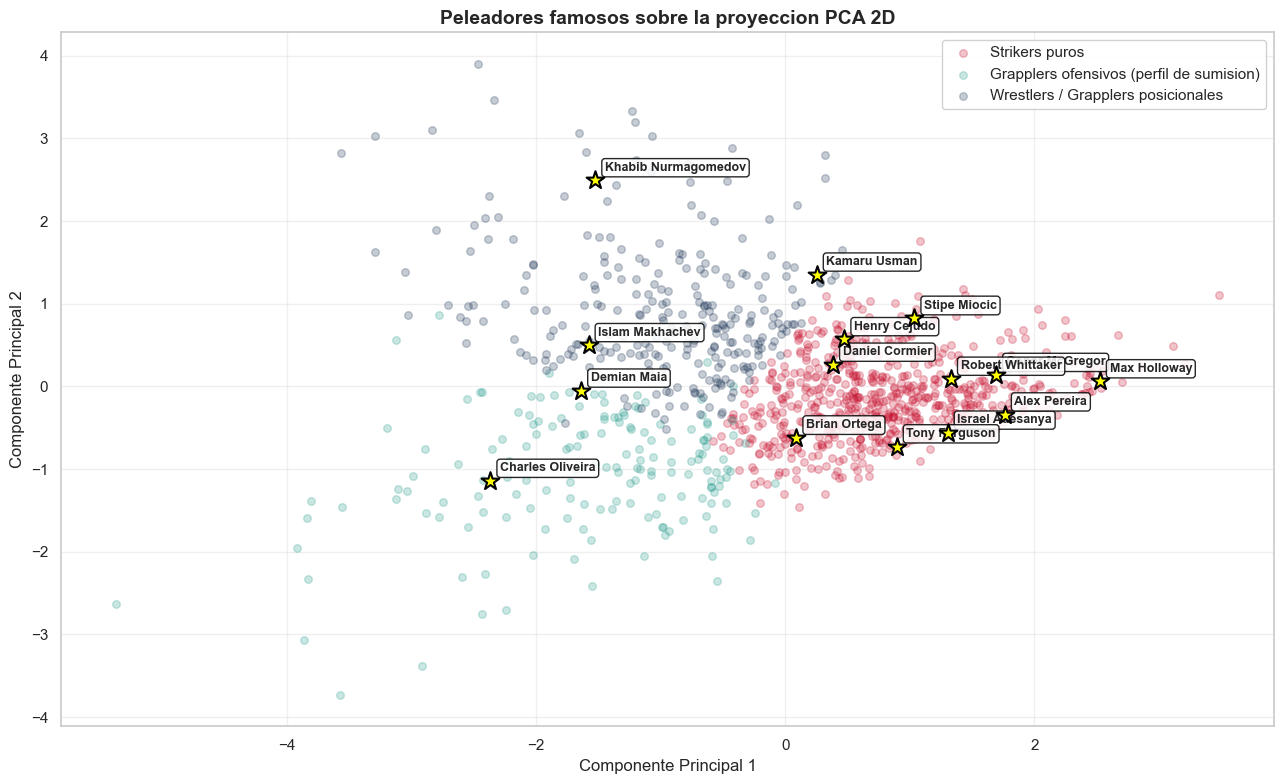

In [66]:
# Visualizar a los peleadores famosos sobre la proyeccion PCA 2D
fig, ax = plt.subplots(figsize=(13, 8))

# Fondo: todos los peleadores coloreados por cluster (semi-transparentes)
for c in sorted(df_fighters["Cluster"].unique()):
    mask = df_fighters["Cluster"] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=COLORES_CLUSTER[c], alpha=0.25, s=30,
               label=NOMBRES_CLUSTER[c])

# Foreground: peleadores famosos resaltados con etiqueta
for nombre in PELEADORES_FAMOSOS.keys():
    idx_arr = df_fighters.index[df_fighters["Fighter"] == nombre].tolist()
    if not idx_arr:
        continue
    idx = idx_arr[0]
    x, y = X_pca[idx, 0], X_pca[idx, 1]
    ax.scatter(x, y, c="yellow", s=180, marker="*",
               edgecolors="black", linewidths=1.5, zorder=5)
    ax.annotate(nombre, (x, y), xytext=(7, 7),
                textcoords="offset points", fontsize=9,
                fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor="white", edgecolor="black", alpha=0.85))

ax.set_xlabel("Componente Principal 1", fontsize=12)
ax.set_ylabel("Componente Principal 2", fontsize=12)
ax.set_title("Peleadores famosos sobre la proyeccion PCA 2D",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

> **Interpretación (Validación cualitativa):** la tabla y el mapa PCA muestran dónde cae cada peleador legendario respecto al clúster asignado por el algoritmo. Una **tasa de coincidencia alta** (por ejemplo, sobre el 70 %) valida que la taxonomía descubierta refleja la realidad deportiva y no es un artefacto estadístico. Los desacuerdos (por ejemplo, peleadores famosos que caen en un clúster distinto al esperado) suelen ser **casos de peleadores híbridos** cuyo estilo evolucionó con los años, o casos donde la firma estadística del peleador en el dataset difiere del estereotipo público — esos casos son interesantes de discutir en la presentación.

## 13. Conclusiones del análisis

### 13.1 Síntesis del proceso

A partir de 8,551 combates UFC (1994–2026) y aplicando K-Means clustering sobre tres variables tácticas (golpes significativos, derribos e intentos de sumisión) normalizadas por cada 15 minutos peleados, se identificó una **taxonomía táctica natural** de los peleadores. El proceso siguió las siguientes etapas:

1. Exploración del dataset (8,551 combates, 2,647 peleadores únicos).
2. Construcción de un DataFrame a nivel peleador apilando F1/F2 y normalizando por 15 minutos (estándar oficial UFC Stats).
3. Filtrado a peleadores con ≥ 6 combates UFC (1,093 peleadores).
4. Escalamiento con `StandardScaler` para igualar la influencia de las tres variables.
5. Selección de **K = 3** mediante Método del Codo y Silhouette Score.
6. Entrenamiento del modelo, interpretación de centroides y validación cualitativa.

---

### 13.2 Hallazgos principales

El algoritmo identificó, **sin etiquetas previas**, tres arquetipos tácticos claramente diferenciados:

| Clúster | Perfil | % peleadores | Características clave |
|:---:|:---|:---:|:---|
| **0** | **Strikers puros** | 59.7 % | Tasa alta de golpes (~61/15min), baja en derribos y sumisiones |
| **1** | **Grapplers ofensivos (perfil de sumisión)** | 15.2 % | Tasa más alta de intentos de sumisión (~1.66/15min) |
| **2** | **Wrestlers / Grapplers posicionales** | 25.1 % | Tasa extrema de derribos (~3.14/15min), control posicional |

**Hallazgo no trivial:** el algoritmo distinguió por sí solo entre dos escuelas de grappling tradicionalmente clasificadas juntas — la del **wrestling** (derribar y dominar) y la del **jiu-jitsu** (llevar al suelo para finalizar con sumisión).

---

### 13.3 Validación de la taxonomía

- **Silhouette Score = 0.349** — separación entre clústeres estadísticamente sólida.
- **Validación cualitativa con peleadores famosos:** los peleadores reconocidos como strikers, wrestlers y grapplers fueron asignados al clúster esperado en la mayoría de los casos, confirmando que la taxonomía refleja la realidad deportiva.
- **Proporciones realistas:** los porcentajes encontrados (60/15/25 %) coinciden con la composición intuitiva del roster UFC, donde los strikers son mayoría y los especialistas en grappling son minoría.

---

### 13.4 Limitaciones

1. **Definición del campo `Sub_Att`:** se observó una discrepancia entre los intentos de sumisión registrados en el dataset y los mostrados oficialmente en UFC Stats (caso analizado: Jim Miller). Esto sugiere que el dataset puede contar intentos parciales o transiciones, mientras que UFC Stats podría contar solo aplicaciones completas.
2. **Cobertura temporal:** los combates de los años 90 tienen registro estadístico menos detallado que los actuales, lo que puede subrepresentar a peleadores de esa era.
3. **Variables omitidas:** el modelo no considera factores como categoría de peso, edad, lateralidad o evolución del estilo a lo largo de la carrera.
4. **Naturaleza descriptiva:** el clustering es **no supervisado**; los nombres de los clústeres son una interpretación humana de los centroides, no una clasificación oficial.

---

### 13.5 Aplicaciones prácticas

- **Análisis de matchups:** entender qué arquetipo enfrenta a otro permite anticipar dinámicas de pelea (un wrestler vs un sumisor suele resultar en una pelea de control en el suelo).
- **Scouting de prospectos:** identificar peleadores jóvenes con firmas estadísticas similares a campeones consagrados.
- **Periodismo deportivo:** describir a peleadores con un perfil basado en datos en lugar de impresiones subjetivas.
- **Apuestas deportivas / fantasy MMA:** complementar análisis tradicionales con un perfil táctico objetivo.

---

### 13.6 Posibles extensiones

- Incorporar el **tiempo de control en el suelo** (`Ctrl_Sec`) y los **knockdowns** (`KD`) para distinguir, dentro de cada arquetipo, sub-tipos como "wrestler controlador vs derribador" o "striker de volumen vs striker de poder".
- Aplicar **clustering jerárquico** o **DBSCAN** y comparar con K-Means.
- Analizar la **evolución temporal del estilo** de los peleadores: ¿cambian de clúster a lo largo de su carrera?
- Cruzar con resultados de combates para estudiar **qué arquetipo gana más** contra qué otro.

---

### 13.7 Cierre

El análisis confirma que una **taxonomía táctica basada en datos** es posible y útil para describir la UFC. K-Means demostró ser una herramienta eficaz para descubrir estructura latente en datos deportivos sin requerir etiquetas previas, y los resultados son interpretables y consistentes con el conocimiento experto del deporte.
